# ============================================================================
# BrainTumorVQA Phase 05C Clean-Metadata Statistical Confidence and Slice Robustness
# ============================================================================

This notebook consumes clean Phase 05B calibrated four-seed prediction artifacts and
produces fast bootstrap confidence intervals, paired statistical comparisons, and
focused slice-level robustness evidence for the clean-metadata final model claim.

It creates a new result folder and does not overwrite previous Phase 05C notebooks or outputs.

# Dual Environment Compatibility Setup & Install Required Libraries


In [1]:
# ── DUAL ENVIRONMENT COMPATIBILITY & DEPENDENCY SETUP ────────────────────────
import os
import sys
from pathlib import Path

def resolve_project_environment(mount_point: str = "/content/drive") -> tuple[Path, Path]:
    try:
        import google.colab
        from google.colab import drive
        drive.mount(mount_point)
        project_root = Path(mount_point) / "MyDrive" / "AUGR-VQA"
        temp_dir = Path("/content")
        print("Running in Google Colab environment.")
    except ImportError:
        # Running locally (parent of notebooks directory)
        project_root = Path(os.getcwd()).parent.resolve()
        temp_dir = project_root / "temp"
        temp_dir.mkdir(parents=True, exist_ok=True)
        print("Running in Local environment.")
    return project_root, temp_dir

PROJECT_ROOT, TEMP_DIR = resolve_project_environment()
# ─────────────────────────────────────────────────────────────────────────────

import subprocess
import sys

required_packages = [
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "tqdm",
]

for package in required_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Configure Clean Phase 05C Paths

In [2]:
from pathlib import Path
import json
import os
import time


def running_in_colab() -> bool:
    try:
        import google.colab
        return True
    except Exception:
        return False


def ensure_drive_connection(project_dir: Path, mount_point: str = "/content/drive"):
    if not running_in_colab():
        return

    from google.colab import drive

    def probe_path(target: Path):
        probe_target = target if target.exists() else target.parent
        return os.listdir(str(probe_target))

        drive.mount(mount_point)
    try:
        probe_path(project_dir)
    except OSError as exc:
        if getattr(exc, "errno", None) != 107:
            raise
        print("Detected a stale Google Drive mount. Remounting now...")
        try:
            drive.flush_and_unmount()
            time.sleep(2)
        except Exception:
            pass
#         drive.mount(mount_point, force_remount=True)
        time.sleep(2)
        probe_path(project_dir)

    if not project_dir.exists():
        raise FileNotFoundError(f"Project Drive directory not found after mount check: {project_dir}")


LOCAL_PROJECT_DIR = Path.cwd()
# Updated project path to point to the new drive structure
COLAB_PROJECT_DIR = PROJECT_ROOT

PROJECT_DIR = COLAB_PROJECT_DIR if running_in_colab() else LOCAL_PROJECT_DIR
ensure_drive_connection(PROJECT_DIR)

# Corrected paths: phase_5/p5b_final_evaluation_ablation_calibration
PHASE5B_SOURCE_DIR = PROJECT_DIR / "phase_5" / "p5b_final_evaluation_ablation_calibration" / "btumqa_225k_clean_metadata_four_seeds_final_comparison"
PHASE5B_PREDICTIONS_DIR = PHASE5B_SOURCE_DIR / "predictions"
PHASE5B_TABLES_DIR = PHASE5B_SOURCE_DIR / "tables"
PHASE5B_REPORTS_DIR = PHASE5B_SOURCE_DIR / "reports"

# Corrected paths: phase_5/p5c_statistical_confidence_slice_robustness
PHASE5C_BASE_DIR = PROJECT_DIR / "phase_5" / "p5c_statistical_confidence_slice_robustness"

# Fresh Colab runs are Boot2000 by default. This keeps the generated outputs in
# the same Boot2000 result folder used by the reviewer-facing figure cells.
DEFAULT_BOOTSTRAP_REPLICATES = 1000
# DEFAULT_BOOTSTRAP_REPLICATES = 2000
PHASE5C_RUN_FOLDER_NAME = (
    f"btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot{DEFAULT_BOOTSTRAP_REPLICATES}"
)
PHASE5C_DIR = PHASE5C_BASE_DIR / PHASE5C_RUN_FOLDER_NAME
TABLES_DIR = PHASE5C_DIR / "tables"
REPORTS_DIR = PHASE5C_DIR / "reports"
FIGURES_DIR = PHASE5C_DIR / "figures"
DONE_DIR = PHASE5C_DIR / "done"

for path in [PHASE5C_DIR, TABLES_DIR, REPORTS_DIR, FIGURES_DIR, DONE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

PREFIX = "phase5c_clean_metadata_four_seeds"
BOOTSTRAP_GLOBAL_CI_PATH = TABLES_DIR / f"{PREFIX}_bootstrap_ci_global_metrics.csv"
BOOTSTRAP_PAIRWISE_PATH = TABLES_DIR / f"{PREFIX}_bootstrap_pairwise_differences.csv"
KEY_SLICE_ANSWER_PATH = TABLES_DIR / f"{PREFIX}_key_slice_answer_comparison.csv"
KEY_SLICE_CALIBRATION_PATH = TABLES_DIR / f"{PREFIX}_key_slice_calibration_comparison.csv"
KEY_SLICE_QCUR_GAIN_PATH = TABLES_DIR / f"{PREFIX}_key_slice_qcur_gain_summary.csv"
METHOD_SUMMARY_PATH = REPORTS_DIR / f"{PREFIX}_method_summary.json"
FINAL_REPORT_PATH = REPORTS_DIR / f"{PREFIX}_statistical_confidence_slice_robustness_report.json"
DONE_PATH = DONE_DIR / f"{PREFIX}_complete.json"

BOOTSTRAP_ANSWER_FIG_PATH = FIGURES_DIR / f"{PREFIX}_bootstrap_ci_answer_metrics.png"
BOOTSTRAP_PAIRWISE_FIG_PATH = FIGURES_DIR / f"{PREFIX}_bootstrap_pairwise_difference_ci.png"
SLICE_MACRO_F1_FIG_PATH = FIGURES_DIR / f"{PREFIX}_slice_macro_f1_heatmap.png"
SLICE_ECE_GAIN_FIG_PATH = FIGURES_DIR / f"{PREFIX}_slice_ece_qcur_gain_heatmap.png"
SLICE_BRIER_GAIN_FIG_PATH = FIGURES_DIR / f"{PREFIX}_slice_brier_qcur_gain_heatmap.png"
SLICE_NLL_GAIN_FIG_PATH = FIGURES_DIR / f"{PREFIX}_slice_nll_qcur_gain_heatmap.png"
SLICE_AURC_GAIN_FIG_PATH = FIGURES_DIR / f"{PREFIX}_slice_aurc_qcur_gain_heatmap.png"
UNCERTAINTY_SLICE_SUMMARY_FIG_PATH = FIGURES_DIR / f"{PREFIX}_uncertainty_sensitive_slice_summary.png"
REVIEWER_DASHBOARD_FIG_PATH = FIGURES_DIR / f"{PREFIX}_reviewer_summary_dashboard.png"

print("Project directory:", PROJECT_DIR)
print("Clean Phase 05B source directory:", PHASE5B_SOURCE_DIR)
print("Clean Phase 05C output directory:", PHASE5C_DIR)
print("Default bootstrap run folder:", PHASE5C_RUN_FOLDER_NAME)
print("This notebook does not overwrite old Phase 05C result folders.")

Mounted at /content/drive
Project directory: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging
Clean Phase 05B source directory: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison
Clean Phase 05C output directory: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000
Default bootstrap run folder: btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000
This notebook does not overwrite old Phase 05C result folders.


# Clean Phase 05C Configuration

In [4]:
RUN_SEEDS = [42, 1337, 2025, 3407]
N_BOOTSTRAP = 1000
# N_BOOTSTRAP = 2000
if "DEFAULT_BOOTSTRAP_REPLICATES" in globals() and N_BOOTSTRAP != DEFAULT_BOOTSTRAP_REPLICATES:
    raise ValueError(
        f"N_BOOTSTRAP ({N_BOOTSTRAP}) must match DEFAULT_BOOTSTRAP_REPLICATES "
        f"({DEFAULT_BOOTSTRAP_REPLICATES}) so outputs are written to the correct boot folder."
    )
CI_LEVEL = 0.95
RANDOM_STATE = 42
CALIBRATION_BINS = 15
MIN_CONFIDENCE = 1e-6
MIN_SLICE_ROWS = 100
SAVE_FIGURES = True

# auto = try CUDA-backed PyTorch bootstrap first, then fall back to fast NumPy CPU.
BOOTSTRAP_BACKEND = "auto"  # choices: "auto", "cpu", "gpu"
BOOTSTRAP_BATCH_SIZE_CPU = 64
BOOTSTRAP_BATCH_SIZE_GPU = 32

BACKBONE_SPECS = {
    "qadp_prugtm_hybrid_clean": {"label": "QAdp-PRUGTM-Hybrid", "order": 0, "selected": True},
    "prugtm_hybrid_clean": {"label": "PRUGTM-Hybrid", "order": 1, "selected": False},
    "no_ugtm_clean": {"label": "No-UGTM", "order": 2, "selected": False},
    "ugtm_qgca_clean": {"label": "UGTM-QGCA", "order": 3, "selected": False},
}

METHOD_SPECS = {
    "Raw": {"confidence_col": "raw_confidence", "order": 0},
    "Posthoc": {"confidence_col": "posthoc_confidence", "order": 1},
    "Q-CUR": {"confidence_col": "qcur_confidence", "order": 2},
}

METRIC_DIRECTIONS = {
    "accuracy": "higher",
    "macro_f1": "higher",
    "weighted_f1": "higher",
    "ece": "lower",
    "brier": "lower",
    "nll": "lower",
    "aurc": "lower",
}

ANSWER_METRICS = ["accuracy", "macro_f1", "weighted_f1"]
RELIABILITY_METRICS = ["ece", "brier", "nll", "aurc"]

FIXED_SLICE_SPECS = [
    {"slice_id": "question_style__comparative", "slice_type": "question_style", "slice_value": "comparative"},
    {"slice_id": "question_family__more_reliable_region", "slice_type": "question_family", "slice_value": "more_reliable_region"},
    {"slice_id": "question_family__more_uncertain_region", "slice_type": "question_family", "slice_value": "more_uncertain_region"},
]
DYNAMIC_SLICE_COLUMNS = ["ambiguity_flag", "signal_gap_bucket", "region_target_pair"]

REQUIRED_COLUMNS = [
    "split",
    "qa_id",
    "unique_id",
    "question_family",
    "question_style",
    "difficulty_level",
    "ambiguity_flag",
    "signal_gap_bucket",
    "region_target_primary",
    "region_target_secondary",
    "region_target_pair",
    "gold_answer",
    "predicted_answer",
    "is_correct",
    "raw_confidence",
    "posthoc_confidence",
    "qcur_confidence",
]

print("Run seeds:", RUN_SEEDS)
print("Bootstrap replicates:", N_BOOTSTRAP)
print("Bootstrap backend request:", BOOTSTRAP_BACKEND)
print("Clean backbones:", [spec["label"] for spec in BACKBONE_SPECS.values()])

Run seeds: [42, 1337, 2025, 3407]
Bootstrap replicates: 1000
Bootstrap backend request: auto
Clean backbones: ['QAdp-PRUGTM-Hybrid', 'PRUGTM-Hybrid', 'No-UGTM', 'UGTM-QGCA']


# Imports and Metric Helpers

In [5]:
from collections import defaultdict
from datetime import datetime, timezone
from itertools import combinations
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)


def seed_tag(run_seed: int) -> str:
    return f"seed_{int(run_seed)}"


def clamp_probs(values):
    return np.clip(np.asarray(values, dtype=np.float64), MIN_CONFIDENCE, 1.0 - MIN_CONFIDENCE)


def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, list):
        return [json_safe(v) for v in value]
    if isinstance(value, tuple):
        return [json_safe(v) for v in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return None if not np.isfinite(value) else float(value)
    if isinstance(value, np.ndarray):
        return json_safe(value.tolist())
    if pd.isna(value) if isinstance(value, float) else False:
        return None
    return value


def ci_bounds(values, ci_level=CI_LEVEL):
    values = np.asarray(values, dtype=np.float64)
    alpha = 1.0 - ci_level
    return (
        float(np.nanquantile(values, alpha / 2.0)),
        float(np.nanquantile(values, 1.0 - alpha / 2.0)),
    )


def summarize_bootstrap(values):
    values = np.asarray(values, dtype=np.float64)
    lower, upper = ci_bounds(values)
    return {
        "bootstrap_mean": float(np.nanmean(values)),
        "bootstrap_std": float(np.nanstd(values, ddof=1)),
        "ci_lower": lower,
        "ci_upper": upper,
    }


def compute_ece_numpy(correct, confidence, n_bins=CALIBRATION_BINS):
    correct = np.asarray(correct, dtype=np.float64)
    confidence = clamp_probs(confidence)
    bin_ids = np.minimum((confidence * n_bins).astype(np.int64), n_bins - 1)
    ece = 0.0
    n = float(len(correct))
    for bin_idx in range(n_bins):
        mask = bin_ids == bin_idx
        count = int(mask.sum())
        if count == 0:
            continue
        ece += (count / n) * abs(float(confidence[mask].mean()) - float(correct[mask].mean()))
    return float(ece)


def compute_aurc_numpy(correct, confidence):
    correct = np.asarray(correct, dtype=np.float64)
    confidence = clamp_probs(confidence)
    if len(correct) == 0:
        return float("nan")
    order = np.argsort(-confidence)
    errors = 1.0 - correct[order]
    cumulative_errors = np.cumsum(errors)
    coverage_counts = np.arange(1, len(errors) + 1, dtype=np.float64)
    risk = cumulative_errors / coverage_counts
    coverage = coverage_counts / float(len(errors))
    return float(np_trapezoid(risk, coverage))


def np_trapezoid(y, x, axis=-1):
    if hasattr(np, "trapezoid"):
        return np.trapezoid(y, x, axis=axis)
    return np.trapz(y, x, axis=axis)


def f1_from_encoded_numpy(gold_ids, pred_ids, n_classes):
    gold_ids = np.asarray(gold_ids, dtype=np.int64)
    pred_ids = np.asarray(pred_ids, dtype=np.int64)
    cm = np.bincount(gold_ids * n_classes + pred_ids, minlength=n_classes * n_classes).reshape(n_classes, n_classes)
    tp = np.diag(cm).astype(np.float64)
    support = cm.sum(axis=1).astype(np.float64)
    predicted = cm.sum(axis=0).astype(np.float64)
    denom = 2.0 * tp + (predicted - tp) + (support - tp)
    f1 = np.divide(2.0 * tp, denom, out=np.zeros_like(tp), where=denom > 0)
    present = (support + predicted) > 0
    macro_f1 = float(f1[present].mean()) if present.any() else float("nan")
    weighted_f1 = float((f1 * support).sum() / support.sum()) if support.sum() > 0 else float("nan")
    return macro_f1, weighted_f1


def compute_metrics_from_arrays(gold_ids, pred_ids, correct, confidence, n_classes):
    confidence = clamp_probs(confidence)
    correct = np.asarray(correct, dtype=np.float64)
    macro_f1, weighted_f1 = f1_from_encoded_numpy(gold_ids, pred_ids, n_classes)
    return {
        "n": int(len(correct)),
        "accuracy": float(correct.mean()),
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "ece": compute_ece_numpy(correct, confidence),
        "brier": float(np.mean((confidence - correct) ** 2)),
        "nll": float(np.mean(-(correct * np.log(confidence) + (1.0 - correct) * np.log(1.0 - confidence)))),
        "aurc": compute_aurc_numpy(correct, confidence),
    }


def save_dataframe(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved {len(df):,} rows -> {path}")


def save_figure(fig, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=220, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print("Saved figure:", path)

# Load and Validate Clean Phase 05B Calibrated Predictions

In [6]:
def prediction_path(backbone_key: str, run_seed: int, split: str = "test") -> Path:
    return PHASE5B_PREDICTIONS_DIR / backbone_key / seed_tag(run_seed) / f"{split}_calibrated_predictions.csv"


def load_prediction_file(backbone_key: str, run_seed: int, split: str = "test") -> pd.DataFrame:
    path = prediction_path(backbone_key, run_seed, split)
    if not path.exists():
        raise FileNotFoundError(f"Missing required clean Phase 05B prediction file: {path}")

    df = pd.read_csv(path)
    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f"{path} missing required columns: {missing}")

    keep_cols = REQUIRED_COLUMNS + [col for col in ["aux_gate_mean", "attended_uncertainty"] if col in df.columns]
    df = df[keep_cols].copy()
    df["backbone_key"] = backbone_key
    df["backbone"] = BACKBONE_SPECS[backbone_key]["label"]
    df["run_seed"] = int(run_seed)
    df["seed_tag"] = seed_tag(run_seed)
    df["source_path"] = str(path)
    df["is_correct"] = df["is_correct"].astype(int)

    for method_spec in METHOD_SPECS.values():
        col = method_spec["confidence_col"]
        df[col] = clamp_probs(df[col].astype(float).to_numpy())

    recomputed_correct = (df["gold_answer"].astype(str) == df["predicted_answer"].astype(str)).astype(int)
    if not np.array_equal(df["is_correct"].to_numpy(), recomputed_correct.to_numpy()):
        mismatch_count = int((df["is_correct"].to_numpy() != recomputed_correct.to_numpy()).sum())
        print(f"Warning: correcting {mismatch_count} is_correct mismatches in {path}")
        df["is_correct"] = recomputed_correct

    if split == "test" and len(df) != 33750:
        raise ValueError(f"{path} has {len(df)} rows; expected 33750 test rows.")

    return df


prediction_runs = {}
loaded_frames = []

for backbone_key in BACKBONE_SPECS:
    prediction_runs[backbone_key] = {}
    for run_seed in RUN_SEEDS:
        df = load_prediction_file(backbone_key, run_seed, split="test")
        prediction_runs[backbone_key][run_seed] = df
        loaded_frames.append(df)
        print(
            BACKBONE_SPECS[backbone_key]["label"],
            seed_tag(run_seed),
            "| rows:",
            len(df),
            "| accuracy:",
            f"{df['is_correct'].mean():.6f}",
        )

all_predictions_df = pd.concat(loaded_frames, ignore_index=True)
answer_labels = sorted(set(all_predictions_df["gold_answer"].astype(str)) | set(all_predictions_df["predicted_answer"].astype(str)))
label_to_id = {label: idx for idx, label in enumerate(answer_labels)}
N_CLASSES = len(answer_labels)

print("Loaded calibrated prediction rows:", len(all_predictions_df))
print("Answer classes:", N_CLASSES)

QAdp-PRUGTM-Hybrid seed_42 | rows: 33750 | accuracy: 0.911674
QAdp-PRUGTM-Hybrid seed_1337 | rows: 33750 | accuracy: 0.929274
QAdp-PRUGTM-Hybrid seed_2025 | rows: 33750 | accuracy: 0.911556
QAdp-PRUGTM-Hybrid seed_3407 | rows: 33750 | accuracy: 0.893215
PRUGTM-Hybrid seed_42 | rows: 33750 | accuracy: 0.899467
PRUGTM-Hybrid seed_1337 | rows: 33750 | accuracy: 0.904148
PRUGTM-Hybrid seed_2025 | rows: 33750 | accuracy: 0.903289
PRUGTM-Hybrid seed_3407 | rows: 33750 | accuracy: 0.899437
No-UGTM seed_42 | rows: 33750 | accuracy: 0.894311
No-UGTM seed_1337 | rows: 33750 | accuracy: 0.890370
No-UGTM seed_2025 | rows: 33750 | accuracy: 0.889956
No-UGTM seed_3407 | rows: 33750 | accuracy: 0.890607
UGTM-QGCA seed_42 | rows: 33750 | accuracy: 0.897422
UGTM-QGCA seed_1337 | rows: 33750 | accuracy: 0.892593
UGTM-QGCA seed_2025 | rows: 33750 | accuracy: 0.887704
UGTM-QGCA seed_3407 | rows: 33750 | accuracy: 0.885926
Loaded calibrated prediction rows: 540000
Answer classes: 23


# Prepare Fast Bootstrap Arrays and Observed Metrics

In [7]:
array_runs = {}
for backbone_key in BACKBONE_SPECS:
    array_runs[backbone_key] = {}
    for run_seed in RUN_SEEDS:
        df = prediction_runs[backbone_key][run_seed]
        array_runs[backbone_key][run_seed] = {
            "gold_ids": df["gold_answer"].astype(str).map(label_to_id).to_numpy(dtype=np.int64),
            "pred_ids": df["predicted_answer"].astype(str).map(label_to_id).to_numpy(dtype=np.int64),
            "correct": df["is_correct"].to_numpy(dtype=np.float64),
            "confidence": {
                method_name: df[method_spec["confidence_col"]].to_numpy(dtype=np.float64)
                for method_name, method_spec in METHOD_SPECS.items()
            },
        }


observed_rows = []
for backbone_key in BACKBONE_SPECS:
    for run_seed in RUN_SEEDS:
        arrays = array_runs[backbone_key][run_seed]
        answer_metrics = None
        for method_name in METHOD_SPECS:
            metrics = compute_metrics_from_arrays(
                arrays["gold_ids"],
                arrays["pred_ids"],
                arrays["correct"],
                arrays["confidence"][method_name],
                N_CLASSES,
            )
            if method_name == "Q-CUR":
                answer_metrics = metrics
            else:
                metrics["accuracy"] = answer_metrics["accuracy"] if answer_metrics else metrics["accuracy"]
                metrics["macro_f1"] = answer_metrics["macro_f1"] if answer_metrics else metrics["macro_f1"]
                metrics["weighted_f1"] = answer_metrics["weighted_f1"] if answer_metrics else metrics["weighted_f1"]
            row = {
                "backbone_key": backbone_key,
                "backbone": BACKBONE_SPECS[backbone_key]["label"],
                "run_seed": int(run_seed),
                "seed_tag": seed_tag(run_seed),
                "method": method_name,
            }
            row.update(metrics)
            observed_rows.append(row)

observed_run_df = pd.DataFrame(observed_rows)
observed_global_summary_df = (
    observed_run_df
    .groupby(["backbone_key", "backbone", "method"], as_index=False)
    .agg(
        num_runs=("run_seed", "nunique"),
        accuracy_mean=("accuracy", "mean"),
        macro_f1_mean=("macro_f1", "mean"),
        weighted_f1_mean=("weighted_f1", "mean"),
        ece_mean=("ece", "mean"),
        brier_mean=("brier", "mean"),
        nll_mean=("nll", "mean"),
        aurc_mean=("aurc", "mean"),
    )
)

# Sanity check against sklearn on one run.
sanity_df = prediction_runs["qadp_prugtm_hybrid_clean"][1337]
sanity_arrays = array_runs["qadp_prugtm_hybrid_clean"][1337]
fast_metrics = compute_metrics_from_arrays(
    sanity_arrays["gold_ids"],
    sanity_arrays["pred_ids"],
    sanity_arrays["correct"],
    sanity_arrays["confidence"]["Q-CUR"],
    N_CLASSES,
)
sk_accuracy = accuracy_score(sanity_df["gold_answer"].astype(str), sanity_df["predicted_answer"].astype(str))
sk_macro = f1_score(sanity_df["gold_answer"].astype(str), sanity_df["predicted_answer"].astype(str), average="macro", zero_division=0)
sk_weighted = f1_score(sanity_df["gold_answer"].astype(str), sanity_df["predicted_answer"].astype(str), average="weighted", zero_division=0)
print("Sanity check QAdp seed_1337:")
print("  fast/sklearn accuracy:", f"{fast_metrics['accuracy']:.8f}", f"{sk_accuracy:.8f}")
print("  fast/sklearn macro-F1:", f"{fast_metrics['macro_f1']:.8f}", f"{sk_macro:.8f}")
print("  fast/sklearn weighted-F1:", f"{fast_metrics['weighted_f1']:.8f}", f"{sk_weighted:.8f}")

if not np.isclose(fast_metrics["accuracy"], sk_accuracy, atol=1e-12):
    raise RuntimeError("Fast accuracy sanity check failed.")
if not np.isclose(fast_metrics["macro_f1"], sk_macro, atol=1e-12):
    raise RuntimeError("Fast macro-F1 sanity check failed.")
if not np.isclose(fast_metrics["weighted_f1"], sk_weighted, atol=1e-12):
    raise RuntimeError("Fast weighted-F1 sanity check failed.")

display(observed_global_summary_df[
    (observed_global_summary_df["method"] == "Q-CUR")
][["backbone", "method", "accuracy_mean", "macro_f1_mean", "weighted_f1_mean", "ece_mean", "brier_mean", "nll_mean", "aurc_mean"]])

Sanity check QAdp seed_1337:
  fast/sklearn accuracy: 0.92927407 0.92927407
  fast/sklearn macro-F1: 0.92004105 0.92004105
  fast/sklearn weighted-F1: 0.93147526 0.93147526


,backbone,method,accuracy_mean,macro_f1_mean,weighted_f1_mean,ece_mean,brier_mean,nll_mean,aurc_mean
1,No-UGTM,Q-CUR,0.891311,0.892008,0.895013,0.020570,0.067051,0.215549,0.016552
4,PRUGTM-Hybrid,Q-CUR,0.901585,0.900537,0.904294,0.021532,0.062786,0.202839,0.014241
7,QAdp-PRUGTM-Hybrid,Q-CUR,0.911430,0.907572,0.914174,0.019947,0.056616,0.185718,0.012078
10,UGTM-QGCA,Q-CUR,0.890911,0.891312,0.894473,0.021185,0.067423,0.216369,0.016724


# Fast Seed-Aware Paired Bootstrap

In [8]:
def resolve_bootstrap_backend():
    requested = str(BOOTSTRAP_BACKEND).lower().strip()
    if requested not in {"auto", "cpu", "gpu"}:
        raise ValueError("BOOTSTRAP_BACKEND must be one of: auto, cpu, gpu")
    if requested == "cpu":
        return "cpu", {"requested": requested, "actual": "cpu", "reason": "CPU explicitly requested"}
    try:
        import torch
        if torch.cuda.is_available():
            name = torch.cuda.get_device_name(0)
            return "gpu", {"requested": requested, "actual": "gpu", "device": name, "reason": "CUDA available"}
        if requested == "gpu":
            print("GPU was requested but CUDA is unavailable. Falling back to fast CPU.")
        return "cpu", {"requested": requested, "actual": "cpu", "reason": "CUDA unavailable"}
    except Exception as exc:
        if requested == "gpu":
            print("GPU was requested but PyTorch/CUDA setup failed. Falling back to fast CPU:", repr(exc))
        return "cpu", {"requested": requested, "actual": "cpu", "reason": f"PyTorch unavailable or failed: {exc!r}"}


def compute_batch_metrics_numpy(sample_gold, sample_pred, sample_correct, sample_conf):
    sample_gold = np.asarray(sample_gold, dtype=np.int64)
    sample_pred = np.asarray(sample_pred, dtype=np.int64)
    sample_correct = np.asarray(sample_correct, dtype=np.float64)
    sample_conf = clamp_probs(sample_conf)
    batch_n, n_rows = sample_correct.shape

    accuracy = sample_correct.mean(axis=1)
    codes = sample_gold * N_CLASSES + sample_pred
    offsets = (np.arange(batch_n, dtype=np.int64)[:, None] * (N_CLASSES * N_CLASSES))
    cm = np.bincount(
        (codes + offsets).ravel(),
        minlength=batch_n * N_CLASSES * N_CLASSES,
    ).reshape(batch_n, N_CLASSES, N_CLASSES).astype(np.float64)
    tp = np.diagonal(cm, axis1=1, axis2=2)
    support = cm.sum(axis=2)
    predicted = cm.sum(axis=1)
    denom = 2.0 * tp + (predicted - tp) + (support - tp)
    f1 = np.divide(2.0 * tp, denom, out=np.zeros_like(tp), where=denom > 0)
    present = (support + predicted) > 0
    macro_f1 = np.divide((f1 * present).sum(axis=1), present.sum(axis=1), out=np.zeros(batch_n), where=present.sum(axis=1) > 0)
    weighted_f1 = np.divide((f1 * support).sum(axis=1), support.sum(axis=1), out=np.zeros(batch_n), where=support.sum(axis=1) > 0)

    brier = ((sample_conf - sample_correct) ** 2).mean(axis=1)
    nll = (-(sample_correct * np.log(sample_conf) + (1.0 - sample_correct) * np.log(1.0 - sample_conf))).mean(axis=1)

    bin_ids = np.minimum((sample_conf * CALIBRATION_BINS).astype(np.int64), CALIBRATION_BINS - 1)
    ece = np.zeros(batch_n, dtype=np.float64)
    for bin_idx in range(CALIBRATION_BINS):
        mask = bin_ids == bin_idx
        counts = mask.sum(axis=1)
        conf_sums = (sample_conf * mask).sum(axis=1)
        correct_sums = (sample_correct * mask).sum(axis=1)
        valid = counts > 0
        mean_conf = np.divide(conf_sums, counts, out=np.zeros(batch_n), where=valid)
        mean_acc = np.divide(correct_sums, counts, out=np.zeros(batch_n), where=valid)
        ece += (counts / float(n_rows)) * np.abs(mean_conf - mean_acc)

    order = np.argsort(-sample_conf, axis=1)
    sorted_correct = np.take_along_axis(sample_correct, order, axis=1)
    errors = 1.0 - sorted_correct
    cumulative_errors = np.cumsum(errors, axis=1)
    coverage_counts = np.arange(1, n_rows + 1, dtype=np.float64)
    risk = cumulative_errors / coverage_counts[None, :]
    coverage = coverage_counts / float(n_rows)
    aurc = np_trapezoid(risk, coverage, axis=1)

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "ece": ece,
        "brier": brier,
        "nll": nll,
        "aurc": aurc,
    }


def bootstrap_cpu():
    rng = np.random.default_rng(RANDOM_STATE)
    metric_distributions = {
        (backbone_key, method_name, metric): np.zeros(N_BOOTSTRAP, dtype=np.float64)
        for backbone_key in BACKBONE_SPECS
        for method_name in METHOD_SPECS
        for metric in METRIC_DIRECTIONS
    }
    batch_size = int(BOOTSTRAP_BATCH_SIZE_CPU)
    started = time.perf_counter()
    pbar = tqdm(total=N_BOOTSTRAP, desc="Fast CPU bootstrap", unit="replicate")

    for batch_start in range(0, N_BOOTSTRAP, batch_size):
        batch_end = min(N_BOOTSTRAP, batch_start + batch_size)
        batch_n = batch_end - batch_start
        seed_indices = {}
        for run_seed in RUN_SEEDS:
            n_rows = len(prediction_runs[next(iter(BACKBONE_SPECS))][run_seed])
            seed_indices[run_seed] = rng.integers(0, n_rows, size=(batch_n, n_rows), endpoint=False, dtype=np.int32)

        batch_slice = slice(batch_start, batch_end)
        for run_seed in RUN_SEEDS:
            sample_idx = seed_indices[run_seed]
            for backbone_key in BACKBONE_SPECS:
                arrays = array_runs[backbone_key][run_seed]
                sample_gold = arrays["gold_ids"][sample_idx]
                sample_pred = arrays["pred_ids"][sample_idx]
                sample_correct = arrays["correct"][sample_idx]
                answer_metric_batch = None
                for method_name in METHOD_SPECS:
                    sample_conf = arrays["confidence"][method_name][sample_idx]
                    metrics = compute_batch_metrics_numpy(sample_gold, sample_pred, sample_correct, sample_conf)
                    if method_name == "Q-CUR":
                        answer_metric_batch = metrics
                    elif answer_metric_batch is not None:
                        for metric in ANSWER_METRICS:
                            metrics[metric] = answer_metric_batch[metric]
                    for metric in METRIC_DIRECTIONS:
                        metric_distributions[(backbone_key, method_name, metric)][batch_slice] += metrics[metric] / float(len(RUN_SEEDS))
        pbar.update(batch_n)

    pbar.close()
    elapsed = time.perf_counter() - started
    return metric_distributions, {"batch_size": batch_size, "elapsed_seconds": elapsed}


def bootstrap_gpu():
    import torch

    device = torch.device("cuda")
    torch.manual_seed(RANDOM_STATE)
    metric_distributions = {
        (backbone_key, method_name, metric): np.zeros(N_BOOTSTRAP, dtype=np.float64)
        for backbone_key in BACKBONE_SPECS
        for method_name in METHOD_SPECS
        for metric in METRIC_DIRECTIONS
    }
    tensor_runs = {}
    for backbone_key in BACKBONE_SPECS:
        tensor_runs[backbone_key] = {}
        for run_seed in RUN_SEEDS:
            arrays = array_runs[backbone_key][run_seed]
            tensor_runs[backbone_key][run_seed] = {
                "gold_ids": torch.as_tensor(arrays["gold_ids"], dtype=torch.long, device=device),
                "pred_ids": torch.as_tensor(arrays["pred_ids"], dtype=torch.long, device=device),
                "correct": torch.as_tensor(arrays["correct"], dtype=torch.float32, device=device),
                "confidence": {
                    method_name: torch.as_tensor(arrays["confidence"][method_name], dtype=torch.float32, device=device)
                    for method_name in METHOD_SPECS
                },
            }

    def metrics_torch_batch(gold, pred, correct, conf):
        conf = torch.clamp(conf, MIN_CONFIDENCE, 1.0 - MIN_CONFIDENCE)
        batch_n, n_rows = correct.shape
        accuracy = correct.mean(dim=1)

        offsets = torch.arange(batch_n, device=device, dtype=torch.long).view(-1, 1) * (N_CLASSES * N_CLASSES)
        codes = gold * N_CLASSES + pred + offsets
        cm = torch.bincount(
            codes.reshape(-1),
            minlength=batch_n * N_CLASSES * N_CLASSES,
        ).reshape(batch_n, N_CLASSES, N_CLASSES).float()
        tp = torch.diagonal(cm, dim1=1, dim2=2)
        support = cm.sum(dim=2)
        predicted = cm.sum(dim=1)
        denom = 2.0 * tp + (predicted - tp) + (support - tp)
        f1 = torch.where(denom > 0, 2.0 * tp / denom, torch.zeros_like(tp))
        present = (support + predicted) > 0
        macro_f1 = torch.where(
            present.sum(dim=1) > 0,
            (f1 * present).sum(dim=1) / present.sum(dim=1).clamp_min(1),
            torch.zeros(batch_n, device=device),
        )
        weighted_f1 = torch.where(
            support.sum(dim=1) > 0,
            (f1 * support).sum(dim=1) / support.sum(dim=1).clamp_min(1),
            torch.zeros(batch_n, device=device),
        )

        bin_ids = torch.clamp((conf * CALIBRATION_BINS).long(), max=CALIBRATION_BINS - 1)
        ece = torch.zeros(batch_n, device=device)
        for bin_idx in range(CALIBRATION_BINS):
            mask = bin_ids == bin_idx
            counts = mask.sum(dim=1).float()
            conf_sums = (conf * mask).sum(dim=1)
            correct_sums = (correct * mask).sum(dim=1)
            valid = counts > 0
            mean_conf = torch.where(valid, conf_sums / counts.clamp_min(1.0), torch.zeros_like(counts))
            mean_acc = torch.where(valid, correct_sums / counts.clamp_min(1.0), torch.zeros_like(counts))
            ece = ece + (counts / float(n_rows)) * torch.abs(mean_conf - mean_acc)

        brier = torch.mean((conf - correct) ** 2, dim=1)
        nll = torch.mean(-(correct * torch.log(conf) + (1.0 - correct) * torch.log(1.0 - conf)), dim=1)

        order = torch.argsort(conf, dim=1, descending=True)
        sorted_correct = torch.gather(correct, 1, order)
        errors = 1.0 - sorted_correct
        cumulative_errors = torch.cumsum(errors, dim=1)
        coverage_counts = torch.arange(1, n_rows + 1, device=device, dtype=torch.float32)
        risk = cumulative_errors / coverage_counts.view(1, -1)
        coverage = coverage_counts / float(n_rows)
        if hasattr(torch, "trapezoid"):
            aurc = torch.trapezoid(risk, coverage, dim=1)
        else:
            aurc = torch.trapz(risk, coverage, dim=1)

        return {
            "accuracy": accuracy,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "ece": ece,
            "brier": brier,
            "nll": nll,
            "aurc": aurc,
        }

    batch_size = int(BOOTSTRAP_BATCH_SIZE_GPU)
    started = time.perf_counter()
    pbar = tqdm(total=N_BOOTSTRAP, desc="CUDA bootstrap", unit="replicate")

    for batch_start in range(0, N_BOOTSTRAP, batch_size):
        batch_end = min(N_BOOTSTRAP, batch_start + batch_size)
        batch_n = batch_end - batch_start
        seed_indices = {}
        for run_seed in RUN_SEEDS:
            n_rows = len(prediction_runs[next(iter(BACKBONE_SPECS))][run_seed])
            seed_indices[run_seed] = torch.randint(0, n_rows, (batch_n, n_rows), device=device)

        batch_slice = slice(batch_start, batch_end)
        for run_seed in RUN_SEEDS:
            idx = seed_indices[run_seed]
            for backbone_key in BACKBONE_SPECS:
                arrays = tensor_runs[backbone_key][run_seed]
                sample_gold = arrays["gold_ids"][idx]
                sample_pred = arrays["pred_ids"][idx]
                sample_correct = arrays["correct"][idx]
                answer_metric_batch = None
                for method_name in METHOD_SPECS:
                    sample_conf = arrays["confidence"][method_name][idx]
                    metrics = metrics_torch_batch(sample_gold, sample_pred, sample_correct, sample_conf)
                    if method_name == "Q-CUR":
                        answer_metric_batch = metrics
                    elif answer_metric_batch is not None:
                        for metric in ANSWER_METRICS:
                            metrics[metric] = answer_metric_batch[metric]
                    for metric in METRIC_DIRECTIONS:
                        metric_distributions[(backbone_key, method_name, metric)][batch_slice] += (
                            metrics[metric].detach().cpu().numpy() / float(len(RUN_SEEDS))
                        )
        pbar.update(batch_n)
        torch.cuda.empty_cache()

    pbar.close()
    elapsed = time.perf_counter() - started
    return metric_distributions, {"batch_size": batch_size, "elapsed_seconds": elapsed}


backend, backend_metadata = resolve_bootstrap_backend()
print("Resolved bootstrap backend:", backend_metadata)

try:
    if backend == "gpu":
        metric_distributions, runtime_metadata = bootstrap_gpu()
    else:
        metric_distributions, runtime_metadata = bootstrap_cpu()
except RuntimeError as exc:
    if backend == "gpu":
        print("GPU bootstrap failed. Falling back to fast CPU. Error:", repr(exc))
        backend = "cpu"
        backend_metadata["actual"] = "cpu"
        backend_metadata["fallback_error"] = repr(exc)
        metric_distributions, runtime_metadata = bootstrap_cpu()
    else:
        raise

backend_metadata.update(runtime_metadata)
print("Bootstrap runtime metadata:", backend_metadata)

bootstrap_global_rows = []
for backbone_key in BACKBONE_SPECS:
    for method_name in METHOD_SPECS:
        observed_row = observed_global_summary_df[
            (observed_global_summary_df["backbone_key"] == backbone_key)
            & (observed_global_summary_df["method"] == method_name)
        ].iloc[0]
        for metric in METRIC_DIRECTIONS:
            dist = metric_distributions[(backbone_key, method_name, metric)]
            row = {
                "backbone_key": backbone_key,
                "backbone": BACKBONE_SPECS[backbone_key]["label"],
                "method": method_name,
                "metric": metric,
                "metric_direction": METRIC_DIRECTIONS[metric],
                "observed_mean": float(observed_row[f"{metric}_mean"]),
                "n_bootstrap": N_BOOTSTRAP,
            }
            row.update(summarize_bootstrap(dist))
            bootstrap_global_rows.append(row)

bootstrap_global_ci_df = pd.DataFrame(bootstrap_global_rows)
save_dataframe(bootstrap_global_ci_df, BOOTSTRAP_GLOBAL_CI_PATH)
display(bootstrap_global_ci_df[
    (bootstrap_global_ci_df["method"] == "Q-CUR")
    & (bootstrap_global_ci_df["metric"].isin(["accuracy", "macro_f1", "ece", "brier", "nll", "aurc"]))
][["backbone", "method", "metric", "observed_mean", "ci_lower", "ci_upper"]])

Resolved bootstrap backend: {'requested': 'auto', 'actual': 'gpu', 'device': 'Tesla T4', 'reason': 'CUDA available'}


CUDA bootstrap:   0%|          | 0/1000 [00:00<?, ?replicate/s]

Bootstrap runtime metadata: {'requested': 'auto', 'actual': 'gpu', 'device': 'Tesla T4', 'reason': 'CUDA available', 'batch_size': 32, 'elapsed_seconds': 12.407677147999493}
Saved 84 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000/tables/phase5c_clean_metadata_four_seeds_bootstrap_ci_global_metrics.csv


,backbone,method,metric,observed_mean,ci_lower,ci_upper
14,QAdp-PRUGTM-Hybrid,Q-CUR,accuracy,0.911430,0.909874,0.912867
15,QAdp-PRUGTM-Hybrid,Q-CUR,macro_f1,0.907572,0.905611,0.909519
17,QAdp-PRUGTM-Hybrid,Q-CUR,ece,0.019947,0.018919,0.021350
18,QAdp-PRUGTM-Hybrid,Q-CUR,brier,0.056616,0.055744,0.057522
19,QAdp-PRUGTM-Hybrid,Q-CUR,nll,0.185718,0.183153,0.188401
20,QAdp-PRUGTM-Hybrid,Q-CUR,aurc,0.012078,0.011705,0.012481
35,PRUGTM-Hybrid,Q-CUR,accuracy,0.901585,0.899919,0.903163
36,PRUGTM-Hybrid,Q-CUR,macro_f1,0.900537,0.898514,0.902482
38,PRUGTM-Hybrid,Q-CUR,ece,0.021532,0.020329,0.023004
39,PRUGTM-Hybrid,Q-CUR,brier,0.062786,0.061819,0.063659


# Pairwise Statistical Comparisons

In [9]:
PAIRWISE_COMPARISONS = []

for left_key, right_key in combinations(BACKBONE_SPECS.keys(), 2):
    left_label = BACKBONE_SPECS[left_key]["label"]
    right_label = BACKBONE_SPECS[right_key]["label"]
    for metric in ANSWER_METRICS:
        PAIRWISE_COMPARISONS.append({
            "comparison_id": f"qcur_{left_key}_vs_{right_key}_{metric}",
            "comparison_group": "qcur_answer_backbone",
            "left_backbone": left_key,
            "left_method": "Q-CUR",
            "right_backbone": right_key,
            "right_method": "Q-CUR",
            "metric": metric,
            "difference_definition": "left_minus_right",
            "paper_interpretation": f"Positive values favor {left_label}; negative values favor {right_label}.",
        })
    for metric in RELIABILITY_METRICS:
        PAIRWISE_COMPARISONS.append({
            "comparison_id": f"qcur_{left_key}_vs_{right_key}_{metric}",
            "comparison_group": "qcur_reliability_backbone",
            "left_backbone": left_key,
            "left_method": "Q-CUR",
            "right_backbone": right_key,
            "right_method": "Q-CUR",
            "metric": metric,
            "difference_definition": "right_minus_left_for_lower_is_better",
            "paper_interpretation": f"Positive values favor {left_label} for lower-is-better {metric}; negative values favor {right_label}.",
        })

for backbone_key, spec in BACKBONE_SPECS.items():
    for baseline_method in ["Raw", "Posthoc"]:
        for metric in RELIABILITY_METRICS:
            PAIRWISE_COMPARISONS.append({
                "comparison_id": f"reliability_{backbone_key}_{baseline_method.lower()}_vs_qcur_{metric}",
                "comparison_group": "within_backbone_qcur_gain",
                "left_backbone": backbone_key,
                "left_method": baseline_method,
                "right_backbone": backbone_key,
                "right_method": "Q-CUR",
                "metric": metric,
                "difference_definition": "baseline_minus_qcur",
                "paper_interpretation": f"Positive values mean Q-CUR improves over {baseline_method} for {spec['label']}.",
            })


def comparison_difference(left_values, right_values, definition):
    left_values = np.asarray(left_values, dtype=np.float64)
    right_values = np.asarray(right_values, dtype=np.float64)
    if definition in {"left_minus_right", "baseline_minus_qcur"}:
        return left_values - right_values
    if definition == "right_minus_left_for_lower_is_better":
        return right_values - left_values
    raise ValueError(f"Unsupported difference definition: {definition}")


def observed_metric(backbone_key: str, method_name: str, metric: str) -> float:
    row = observed_global_summary_df[
        (observed_global_summary_df["backbone_key"] == backbone_key)
        & (observed_global_summary_df["method"] == method_name)
    ].iloc[0]
    return float(row[f"{metric}_mean"])


pairwise_rows = []
for comparison in PAIRWISE_COMPARISONS:
    metric = comparison["metric"]
    left_key = (comparison["left_backbone"], comparison["left_method"], metric)
    right_key = (comparison["right_backbone"], comparison["right_method"], metric)
    diff_dist = comparison_difference(
        metric_distributions[left_key],
        metric_distributions[right_key],
        comparison["difference_definition"],
    )
    observed_left = observed_metric(comparison["left_backbone"], comparison["left_method"], metric)
    observed_right = observed_metric(comparison["right_backbone"], comparison["right_method"], metric)
    observed_diff = float(comparison_difference([observed_left], [observed_right], comparison["difference_definition"])[0])
    lower, upper = ci_bounds(diff_dist)
    p_two_sided = float(2.0 * min(np.mean(diff_dist <= 0.0), np.mean(diff_dist >= 0.0)))
    p_two_sided = min(p_two_sided, 1.0)
    support = "positive_ci" if lower > 0 else "negative_ci" if upper < 0 else "overlaps_zero"
    pairwise_rows.append({
        "comparison_id": comparison["comparison_id"],
        "comparison_group": comparison["comparison_group"],
        "metric": metric,
        "metric_direction": METRIC_DIRECTIONS[metric],
        "left_backbone": comparison["left_backbone"],
        "left_method": comparison["left_method"],
        "right_backbone": comparison["right_backbone"],
        "right_method": comparison["right_method"],
        "difference_definition": comparison["difference_definition"],
        "observed_left": observed_left,
        "observed_right": observed_right,
        "observed_difference": observed_diff,
        "n_bootstrap": N_BOOTSTRAP,
        "ci_lower": lower,
        "ci_upper": upper,
        "bootstrap_mean_difference": float(np.nanmean(diff_dist)),
        "bootstrap_std_difference": float(np.nanstd(diff_dist, ddof=1)),
        "p_two_sided_bootstrap_sign": p_two_sided,
        "ci_support": support,
        "paper_interpretation": comparison["paper_interpretation"],
    })

bootstrap_pairwise_df = pd.DataFrame(pairwise_rows)
save_dataframe(bootstrap_pairwise_df, BOOTSTRAP_PAIRWISE_PATH)
display(bootstrap_pairwise_df.head(30))

Saved 74 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000/tables/phase5c_clean_metadata_four_seeds_bootstrap_pairwise_differences.csv


,comparison_id,comparison_group,metric,metric_direction,left_backbone,left_method,right_backbone,right_method,difference_definition,observed_left,observed_right,observed_difference,n_bootstrap,ci_lower,ci_upper,bootstrap_mean_difference,bootstrap_std_difference,p_two_sided_bootstrap_sign,ci_support,paper_interpretation
0,qcur_qadp_prugtm_hybrid_clean_vs_prugtm_hybrid...,qcur_answer_backbone,accuracy,higher,qadp_prugtm_hybrid_clean,Q-CUR,prugtm_hybrid_clean,Q-CUR,left_minus_right,0.911430,0.901585,0.009844,1000,0.008600,0.011082,0.009828,0.000647,0.000,positive_ci,Positive values favor QAdp-PRUGTM-Hybrid; nega...
1,qcur_qadp_prugtm_hybrid_clean_vs_prugtm_hybrid...,qcur_answer_backbone,macro_f1,higher,qadp_prugtm_hybrid_clean,Q-CUR,prugtm_hybrid_clean,Q-CUR,left_minus_right,0.907572,0.900537,0.007036,1000,0.005508,0.008402,0.007028,0.000743,0.000,positive_ci,Positive values favor QAdp-PRUGTM-Hybrid; nega...
2,qcur_qadp_prugtm_hybrid_clean_vs_prugtm_hybrid...,qcur_answer_backbone,weighted_f1,higher,qadp_prugtm_hybrid_clean,Q-CUR,prugtm_hybrid_clean,Q-CUR,left_minus_right,0.914174,0.904294,0.009880,1000,0.008662,0.011099,0.009863,0.000629,0.000,positive_ci,Positive values favor QAdp-PRUGTM-Hybrid; nega...
3,qcur_qadp_prugtm_hybrid_clean_vs_prugtm_hybrid...,qcur_reliability_backbone,ece,lower,qadp_prugtm_hybrid_clean,Q-CUR,prugtm_hybrid_clean,Q-CUR,right_minus_left_for_lower_is_better,0.019947,0.021532,0.001585,1000,0.000078,0.002835,0.001528,0.000723,0.036,positive_ci,Positive values favor QAdp-PRUGTM-Hybrid for l...
4,qcur_qadp_prugtm_hybrid_clean_vs_prugtm_hybrid...,qcur_reliability_backbone,brier,lower,qadp_prugtm_hybrid_clean,Q-CUR,prugtm_hybrid_clean,Q-CUR,right_minus_left_for_lower_is_better,0.056616,0.062786,0.006170,1000,0.005541,0.006795,0.006156,0.000322,0.000,positive_ci,Positive values favor QAdp-PRUGTM-Hybrid for l...
5,qcur_qadp_prugtm_hybrid_clean_vs_prugtm_hybrid...,qcur_reliability_backbone,nll,lower,qadp_prugtm_hybrid_clean,Q-CUR,prugtm_hybrid_clean,Q-CUR,right_minus_left_for_lower_is_better,0.185718,0.202839,0.017121,1000,0.015447,0.018950,0.017092,0.000913,0.000,positive_ci,Positive values favor QAdp-PRUGTM-Hybrid for l...
6,qcur_qadp_prugtm_hybrid_clean_vs_prugtm_hybrid...,qcur_reliability_backbone,aurc,lower,qadp_prugtm_hybrid_clean,Q-CUR,prugtm_hybrid_clean,Q-CUR,right_minus_left_for_lower_is_better,0.012078,0.014241,0.002163,1000,0.001892,0.002438,0.002161,0.000143,0.000,positive_ci,Positive values favor QAdp-PRUGTM-Hybrid for l...
7,qcur_qadp_prugtm_hybrid_clean_vs_no_ugtm_clean...,qcur_answer_backbone,accuracy,higher,qadp_prugtm_hybrid_clean,Q-CUR,no_ugtm_clean,Q-CUR,left_minus_right,0.911430,0.891311,0.020119,1000,0.018733,0.021378,0.020127,0.000674,0.000,positive_ci,Positive values favor QAdp-PRUGTM-Hybrid; nega...
8,qcur_qadp_prugtm_hybrid_clean_vs_no_ugtm_clean...,qcur_answer_backbone,macro_f1,higher,qadp_prugtm_hybrid_clean,Q-CUR,no_ugtm_clean,Q-CUR,left_minus_right,0.907572,0.892008,0.015564,1000,0.014017,0.017099,0.015592,0.000755,0.000,positive_ci,Positive values favor QAdp-PRUGTM-Hybrid; nega...
9,qcur_qadp_prugtm_hybrid_clean_vs_no_ugtm_clean...,qcur_answer_backbone,weighted_f1,higher,qadp_prugtm_hybrid_clean,Q-CUR,no_ugtm_clean,Q-CUR,left_minus_right,0.914174,0.895013,0.019160,1000,0.017799,0.020393,0.019166,0.000654,0.000,positive_ci,Positive values favor QAdp-PRUGTM-Hybrid; nega...


# Focused Slice-Level Robustness

In [10]:
def build_slice_specs():
    specs = list(FIXED_SLICE_SPECS)
    reference_df = prediction_runs[next(iter(BACKBONE_SPECS))][RUN_SEEDS[0]]
    for column in DYNAMIC_SLICE_COLUMNS:
        for value, group_df in reference_df.groupby(column, dropna=False):
            value = str(value)
            if value == "" or len(group_df) < MIN_SLICE_ROWS:
                continue
            specs.append({
                "slice_id": f"{column}__{value}",
                "slice_type": column,
                "slice_value": value,
            })
    unique = {}
    for spec in specs:
        unique[spec["slice_id"]] = spec
    return list(unique.values())


FOCUSED_SLICE_SPECS = build_slice_specs()
print("Focused slice count:", len(FOCUSED_SLICE_SPECS))
print([spec["slice_id"] for spec in FOCUSED_SLICE_SPECS[:20]])

slice_answer_rows = []
slice_calibration_rows = []

for slice_spec in FOCUSED_SLICE_SPECS:
    slice_type = slice_spec["slice_type"]
    slice_value = slice_spec["slice_value"]
    for backbone_key in BACKBONE_SPECS:
        for run_seed in RUN_SEEDS:
            df = prediction_runs[backbone_key][run_seed]
            slice_df = df[df[slice_type].astype(str) == str(slice_value)].copy()
            if len(slice_df) < MIN_SLICE_ROWS:
                continue
            gold_ids = slice_df["gold_answer"].astype(str).map(label_to_id).to_numpy(dtype=np.int64)
            pred_ids = slice_df["predicted_answer"].astype(str).map(label_to_id).to_numpy(dtype=np.int64)
            correct = slice_df["is_correct"].to_numpy(dtype=np.float64)
            qcur_metrics = compute_metrics_from_arrays(
                gold_ids,
                pred_ids,
                correct,
                slice_df["qcur_confidence"].to_numpy(dtype=np.float64),
                N_CLASSES,
            )
            slice_answer_rows.append({
                "slice_id": slice_spec["slice_id"],
                "slice_type": slice_type,
                "slice_value": slice_value,
                "backbone_key": backbone_key,
                "backbone": BACKBONE_SPECS[backbone_key]["label"],
                "run_seed": int(run_seed),
                "seed_tag": seed_tag(run_seed),
                "n": qcur_metrics["n"],
                "accuracy": qcur_metrics["accuracy"],
                "macro_f1": qcur_metrics["macro_f1"],
                "weighted_f1": qcur_metrics["weighted_f1"],
            })

            for method_name, method_spec in METHOD_SPECS.items():
                metrics = compute_metrics_from_arrays(
                    gold_ids,
                    pred_ids,
                    correct,
                    slice_df[method_spec["confidence_col"]].to_numpy(dtype=np.float64),
                    N_CLASSES,
                )
                if method_name != "Q-CUR":
                    for metric in ANSWER_METRICS:
                        metrics[metric] = qcur_metrics[metric]
                row = {
                    "slice_id": slice_spec["slice_id"],
                    "slice_type": slice_type,
                    "slice_value": slice_value,
                    "backbone_key": backbone_key,
                    "backbone": BACKBONE_SPECS[backbone_key]["label"],
                    "run_seed": int(run_seed),
                    "seed_tag": seed_tag(run_seed),
                    "method": method_name,
                    "confidence_col": method_spec["confidence_col"],
                }
                row.update(metrics)
                slice_calibration_rows.append(row)

slice_answer_run_df = pd.DataFrame(slice_answer_rows)
slice_calibration_run_df = pd.DataFrame(slice_calibration_rows)

key_slice_answer_df = (
    slice_answer_run_df
    .groupby(["slice_id", "slice_type", "slice_value", "backbone_key", "backbone"], as_index=False)
    .agg(
        num_runs=("run_seed", "nunique"),
        n_mean=("n", "mean"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        weighted_f1_mean=("weighted_f1", "mean"),
        weighted_f1_std=("weighted_f1", "std"),
    )
)

key_slice_calibration_df = (
    slice_calibration_run_df
    .groupby(["slice_id", "slice_type", "slice_value", "backbone_key", "backbone", "method"], as_index=False)
    .agg(
        num_runs=("run_seed", "nunique"),
        n_mean=("n", "mean"),
        accuracy_mean=("accuracy", "mean"),
        macro_f1_mean=("macro_f1", "mean"),
        weighted_f1_mean=("weighted_f1", "mean"),
        ece_mean=("ece", "mean"),
        brier_mean=("brier", "mean"),
        nll_mean=("nll", "mean"),
        aurc_mean=("aurc", "mean"),
    )
)

gain_rows = []
for slice_id in key_slice_calibration_df["slice_id"].unique():
    for backbone_key in BACKBONE_SPECS:
        qcur_row = key_slice_calibration_df[
            (key_slice_calibration_df["slice_id"] == slice_id)
            & (key_slice_calibration_df["backbone_key"] == backbone_key)
            & (key_slice_calibration_df["method"] == "Q-CUR")
        ]
        if qcur_row.empty:
            continue
        qcur_row = qcur_row.iloc[0]
        for baseline_method in ["Raw", "Posthoc"]:
            baseline_row = key_slice_calibration_df[
                (key_slice_calibration_df["slice_id"] == slice_id)
                & (key_slice_calibration_df["backbone_key"] == backbone_key)
                & (key_slice_calibration_df["method"] == baseline_method)
            ]
            if baseline_row.empty:
                continue
            baseline_row = baseline_row.iloc[0]
            gain_rows.append({
                "slice_id": slice_id,
                "slice_type": qcur_row["slice_type"],
                "slice_value": qcur_row["slice_value"],
                "backbone_key": backbone_key,
                "backbone": qcur_row["backbone"],
                "baseline_method": baseline_method,
                "comparison": f"{baseline_method} -> Q-CUR",
                "ece_gain": float(baseline_row["ece_mean"] - qcur_row["ece_mean"]),
                "brier_gain": float(baseline_row["brier_mean"] - qcur_row["brier_mean"]),
                "nll_gain": float(baseline_row["nll_mean"] - qcur_row["nll_mean"]),
                "aurc_gain": float(baseline_row["aurc_mean"] - qcur_row["aurc_mean"]),
            })

key_slice_qcur_gain_df = pd.DataFrame(gain_rows)

save_dataframe(key_slice_answer_df, KEY_SLICE_ANSWER_PATH)
save_dataframe(key_slice_calibration_df, KEY_SLICE_CALIBRATION_PATH)
save_dataframe(key_slice_qcur_gain_df, KEY_SLICE_QCUR_GAIN_PATH)

display(key_slice_answer_df.head(20))
display(key_slice_qcur_gain_df.head(20))

Focused slice count: 36
['question_style__comparative', 'question_family__more_reliable_region', 'question_family__more_uncertain_region', 'ambiguity_flag__no', 'ambiguity_flag__yes', 'signal_gap_bucket__close_gap', 'signal_gap_bucket__moderate_gap', 'signal_gap_bucket__wide_gap', 'region_target_pair__context|edema', 'region_target_pair__context|enhancing', 'region_target_pair__context|ncr_net', 'region_target_pair__context|tumor', 'region_target_pair__edema|context', 'region_target_pair__edema|edema', 'region_target_pair__edema|enhancing', 'region_target_pair__edema|ncr_net', 'region_target_pair__edema|none', 'region_target_pair__edema|tumor', 'region_target_pair__enhancing|context', 'region_target_pair__enhancing|edema']
Saved 144 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000/tables/phase5c_clean_metadat

,slice_id,slice_type,slice_value,backbone_key,backbone,num_runs,n_mean,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,ambiguity_flag__no,ambiguity_flag,no,no_ugtm_clean,No-UGTM,4,22373.0,0.921222,0.002282,0.652909,0.001675,0.942444,0.001859
1,ambiguity_flag__no,ambiguity_flag,no,prugtm_hybrid_clean,PRUGTM-Hybrid,4,22373.0,0.930899,0.002455,0.655731,0.000421,0.949314,0.001453
2,ambiguity_flag__no,ambiguity_flag,no,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,4,22373.0,0.933759,0.011791,0.666216,0.019583,0.952397,0.009053
3,ambiguity_flag__no,ambiguity_flag,no,ugtm_qgca_clean,UGTM-QGCA,4,22373.0,0.920742,0.005192,0.651899,0.003159,0.941926,0.004682
4,ambiguity_flag__yes,ambiguity_flag,yes,no_ugtm_clean,No-UGTM,4,11377.0,0.832491,0.004724,0.486527,0.011241,0.863721,0.004393
5,ambiguity_flag__yes,ambiguity_flag,yes,prugtm_hybrid_clean,PRUGTM-Hybrid,4,11377.0,0.843940,0.002778,0.485237,0.001265,0.873726,0.001785
6,ambiguity_flag__yes,ambiguity_flag,yes,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,4,11377.0,0.867518,0.022778,0.501574,0.016685,0.894335,0.019784
7,ambiguity_flag__yes,ambiguity_flag,yes,ugtm_qgca_clean,UGTM-QGCA,4,11377.0,0.832249,0.005376,0.479964,0.003292,0.862721,0.005804
8,question_family__more_reliable_region,question_family,more_reliable_region,no_ugtm_clean,No-UGTM,4,2700.0,0.907500,0.009546,0.841576,0.127194,0.907443,0.009773
9,question_family__more_reliable_region,question_family,more_reliable_region,prugtm_hybrid_clean,PRUGTM-Hybrid,4,2700.0,0.923333,0.005918,0.922701,0.005850,0.923273,0.005805


,slice_id,slice_type,slice_value,backbone_key,backbone,baseline_method,comparison,ece_gain,brier_gain,nll_gain,aurc_gain
0,ambiguity_flag__no,ambiguity_flag,no,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Raw,Raw -> Q-CUR,0.123727,0.039865,0.165515,0.022939
1,ambiguity_flag__no,ambiguity_flag,no,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Posthoc,Posthoc -> Q-CUR,-0.000318,0.017669,0.076628,0.022939
2,ambiguity_flag__no,ambiguity_flag,no,prugtm_hybrid_clean,PRUGTM-Hybrid,Raw,Raw -> Q-CUR,0.125128,0.038720,0.159214,0.021348
3,ambiguity_flag__no,ambiguity_flag,no,prugtm_hybrid_clean,PRUGTM-Hybrid,Posthoc,Posthoc -> Q-CUR,-0.000189,0.016876,0.073921,0.021348
4,ambiguity_flag__no,ambiguity_flag,no,no_ugtm_clean,No-UGTM,Raw,Raw -> Q-CUR,0.121624,0.043676,0.170041,0.024699
5,ambiguity_flag__no,ambiguity_flag,no,no_ugtm_clean,No-UGTM,Posthoc,Posthoc -> Q-CUR,-0.000498,0.022551,0.090558,0.024699
6,ambiguity_flag__no,ambiguity_flag,no,ugtm_qgca_clean,UGTM-QGCA,Raw,Raw -> Q-CUR,0.121904,0.042619,0.167077,0.023721
7,ambiguity_flag__no,ambiguity_flag,no,ugtm_qgca_clean,UGTM-QGCA,Posthoc,Posthoc -> Q-CUR,0.000205,0.021470,0.086865,0.023721
8,ambiguity_flag__yes,ambiguity_flag,yes,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Raw,Raw -> Q-CUR,0.077984,0.014958,0.064383,0.010141
9,ambiguity_flag__yes,ambiguity_flag,yes,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,Posthoc,Posthoc -> Q-CUR,-0.015662,-0.000065,0.010427,0.010141


# Minimal Publication Figure Replacement For Current Run

In [11]:
import textwrap


if SAVE_FIGURES:
    minimal_palette = {
        "ink": "#1f2933",
        "muted": "#637381",
        "line": "#b8c2cc",
        "QAdp-PRUGTM-Hybrid": "#7659a6",
        "PRUGTM-Hybrid": "#2a9d8f",
        "No-UGTM": "#c98936",
        "UGTM-QGCA": "#2f6f9f",
        "Raw": "#b85c5c",
        "Posthoc": "#d39b2f",
        "Q-CUR": "#247a69",
    }
    minimal_backbone_order = ["QAdp-PRUGTM-Hybrid", "PRUGTM-Hybrid", "No-UGTM", "UGTM-QGCA"]

    def minimal_axis(ax, title=None, xlabel=None, ylabel=None):
        ax.grid(False)
        if title:
            ax.set_title(title, loc="left", fontsize=13, fontweight="bold", color=minimal_palette["ink"], pad=9)
        ax.set_xlabel(xlabel or "", fontsize=10.5, color=minimal_palette["ink"])
        ax.set_ylabel(ylabel or "", fontsize=10.5, color=minimal_palette["ink"])
        ax.tick_params(axis="both", labelsize=9.5, colors=minimal_palette["ink"])
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        ax.spines["left"].set_color("#d6dde5")
        ax.spines["bottom"].set_color("#d6dde5")

    def clean_model_key(value):
        value = str(value).replace("_clean", "")
        return {
            "qadp_prugtm_hybrid": "QAdp",
            "prugtm_hybrid": "PRUGTM",
            "no_ugtm": "No-UGTM",
            "ugtm_qgca": "UGTM",
        }.get(value, value)

    def clean_slice_label(value, width=42):
        text = str(value)
        replacements = {
            "question_family__": "family: ",
            "question_style__": "style: ",
            "signal_gap_bucket__": "signal gap: ",
            "ambiguity_flag__": "ambiguity: ",
            "region_target_pair__": "region pair: ",
            "more_reliable_region": "more reliable region",
            "more_uncertain_region": "more uncertain region",
            "close_gap": "close gap",
            "moderate_gap": "moderate gap",
            "wide_gap": "wide gap",
            "_": " ",
        }
        for old, new in replacements.items():
            text = text.replace(old, new)
        return "\n".join(textwrap.wrap(text, width=width))

    # 1) Minimal answer CI lollipop.
    answer_plot = bootstrap_global_ci_df[
        (bootstrap_global_ci_df["method"] == "Q-CUR")
        & (bootstrap_global_ci_df["metric"].isin(["accuracy", "macro_f1", "weighted_f1"]))
    ].copy()
    answer_plot["backbone"] = pd.Categorical(answer_plot["backbone"], categories=minimal_backbone_order, ordered=True)
    answer_plot["metric_label"] = answer_plot["metric"].map({
        "accuracy": "Accuracy",
        "macro_f1": "Macro-F1",
        "weighted_f1": "Weighted-F1",
    })

    fig, axes = plt.subplots(1, 3, figsize=(17.5, 5.7), constrained_layout=True)
    for ax, metric_label in zip(axes, ["Accuracy", "Macro-F1", "Weighted-F1"]):
        data = answer_plot[answer_plot["metric_label"] == metric_label].sort_values("backbone")
        y = np.arange(len(data))
        x = data["observed_mean"].astype(float).to_numpy()
        colors = [minimal_palette[label] for label in data["backbone"].astype(str)]
        ax.hlines(y=y, xmin=data["ci_lower"], xmax=data["ci_upper"], color=minimal_palette["line"], linewidth=2.2)
        ax.scatter(x, y, s=78, color=colors, edgecolor="white", linewidth=0.9, zorder=3)
        for xi, yi in zip(x, y):
            ax.text(xi + 0.0012, yi, f"{xi:.4f}", va="center", ha="left", fontsize=8.5, color=minimal_palette["ink"])
        ax.set_yticks(y)
        ax.set_yticklabels(data["backbone"].astype(str))
        ax.invert_yaxis()
        ax.set_xlim(max(0.0, float(data["ci_lower"].min()) - 0.008), min(1.0, float(data["ci_upper"].max()) + 0.022))
        minimal_axis(ax, metric_label, "Mean with 95% bootstrap CI", "")
    fig.suptitle(f"Clean Four-Seed Answer Metrics ({N_BOOTSTRAP} Bootstrap Replicates)", fontsize=16, fontweight="bold", color=minimal_palette["ink"])
    save_figure(fig, BOOTSTRAP_ANSWER_FIG_PATH)

    # 2) Minimal pairwise figure: only key QAdp answer comparisons, no long raw ids.
    pairwise_key = bootstrap_pairwise_df[
        (bootstrap_pairwise_df["comparison_group"] == "qcur_answer_backbone")
        & (bootstrap_pairwise_df["comparison_id"].str.contains("qadp_prugtm_hybrid_clean", regex=False))
        & (bootstrap_pairwise_df["metric"].isin(["accuracy", "macro_f1", "weighted_f1"]))
    ].copy()
    pairwise_key["label"] = pairwise_key.apply(
        lambda row: f"QAdp - {clean_model_key(row['right_backbone'])} · "
        f"{str(row['metric']).replace('accuracy', 'Accuracy').replace('macro_f1', 'Macro-F1').replace('weighted_f1', 'Weighted-F1')}",
        axis=1,
    )
    pairwise_key = pairwise_key.sort_values(["metric", "right_backbone"]).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(11.8, max(5.6, 0.48 * len(pairwise_key))), constrained_layout=True)
    y = np.arange(len(pairwise_key))
    x = pairwise_key["observed_difference"].astype(float).to_numpy()
    support_colors = ["#247a69" if lo > 0 else "#b85c5c" if hi < 0 else "#7b8794" for lo, hi in zip(pairwise_key["ci_lower"], pairwise_key["ci_upper"])]
    ax.hlines(y=y, xmin=pairwise_key["ci_lower"], xmax=pairwise_key["ci_upper"], color=support_colors, linewidth=2.2)
    ax.scatter(x, y, color=support_colors, edgecolor="white", linewidth=0.8, s=65, zorder=3)
    ax.axvline(0.0, color=minimal_palette["ink"], linestyle="--", linewidth=0.9)
    for xi, yi in zip(x, y):
        ax.text(xi + 0.00035, yi, f"{xi:+.4f}", va="center", ha="left", fontsize=8.4, color=minimal_palette["ink"])
    ax.set_yticks(y)
    ax.set_yticklabels(pairwise_key["label"])
    ax.invert_yaxis()
    span = max(abs(float(pairwise_key["ci_lower"].min())), abs(float(pairwise_key["ci_upper"].max())))
    ax.set_xlim(-span * 1.20, span * 1.24)
    minimal_axis(ax, "Key Pairwise Answer Differences", "Difference; positive favors QAdp", "")
    fig.suptitle(f"Paired Bootstrap Difference CIs ({N_BOOTSTRAP} Replicates)", fontsize=16, fontweight="bold", color=minimal_palette["ink"])
    save_figure(fig, BOOTSTRAP_PAIRWISE_FIG_PATH)

    # 3) Minimal focused slice dot plot, replacing the old heatmap file name.
    selected_slice = key_slice_answer_df[key_slice_answer_df["backbone"] == "QAdp-PRUGTM-Hybrid"].copy()
    selected_slice = selected_slice.sort_values("macro_f1_mean", ascending=True).head(12)
    slice_ids = selected_slice["slice_id"].tolist()
    slice_plot = key_slice_answer_df[key_slice_answer_df["slice_id"].isin(slice_ids)].copy()
    slice_plot["backbone"] = pd.Categorical(slice_plot["backbone"], categories=minimal_backbone_order, ordered=True)
    slice_plot["slice_label"] = slice_plot["slice_id"].map(clean_slice_label)
    fig, ax = plt.subplots(figsize=(12.8, max(6.8, 0.62 * len(slice_ids))), constrained_layout=True)
    sns.scatterplot(
        data=slice_plot,
        x="macro_f1_mean",
        y="slice_label",
        hue="backbone",
        hue_order=minimal_backbone_order,
        palette={label: minimal_palette[label] for label in minimal_backbone_order},
        s=88,
        edgecolor="white",
        linewidth=0.8,
        ax=ax,
    )
    ax.set_xlim(max(0.0, float(slice_plot["macro_f1_mean"].min()) - 0.035), min(1.0, float(slice_plot["macro_f1_mean"].max()) + 0.025))
    minimal_axis(ax, "Focused Slice Macro-F1", "Mean Macro-F1", "")
    ax.legend(title="Backbone", frameon=False, bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=9.0, title_fontsize=9.5)
    save_figure(fig, SLICE_MACRO_F1_FIG_PATH)

    # 4) Replace old gain heatmaps with simple selected-model horizontal bars.
    gain_plot = key_slice_qcur_gain_df[
        (key_slice_qcur_gain_df["backbone"] == "QAdp-PRUGTM-Hybrid")
        & (key_slice_qcur_gain_df["baseline_method"] == "Raw")
    ].copy()
    gain_plot = gain_plot.sort_values("aurc_gain", ascending=False).head(12)
    gain_plot["slice_label"] = gain_plot["slice_id"].map(clean_slice_label)
    gain_specs = [
        ("ece_gain", "ECE Gain", SLICE_ECE_GAIN_FIG_PATH),
        ("brier_gain", "Brier Gain", SLICE_BRIER_GAIN_FIG_PATH),
        ("nll_gain", "NLL Gain", SLICE_NLL_GAIN_FIG_PATH),
        ("aurc_gain", "AURC Gain", SLICE_AURC_GAIN_FIG_PATH),
    ]
    for metric_col, title, path in gain_specs:
        fig, ax = plt.subplots(figsize=(11.8, max(5.8, 0.50 * len(gain_plot))), constrained_layout=True)
        colors = ["#247a69" if value >= 0 else "#b85c5c" for value in gain_plot[metric_col]]
        ax.barh(gain_plot["slice_label"], gain_plot[metric_col], color=colors, edgecolor="white", height=0.62)
        ax.axvline(0.0, color=minimal_palette["ink"], linewidth=0.9)
        ax.invert_yaxis()
        minimal_axis(ax, f"QAdp Raw to Q-CUR {title}", "Positive means Q-CUR is lower/better", "")
        save_figure(fig, path)

    # 5) Minimal summary dashboard.
    summary_answer = answer_plot.copy()
    selected_reliability = bootstrap_global_ci_df[
        (bootstrap_global_ci_df["backbone"] == "QAdp-PRUGTM-Hybrid")
        & (bootstrap_global_ci_df["method"].isin(["Raw", "Posthoc", "Q-CUR"]))
        & (bootstrap_global_ci_df["metric"].isin(["ece", "brier", "nll", "aurc"]))
    ].copy()
    selected_reliability["metric_label"] = selected_reliability["metric"].map({"ece": "ECE", "brier": "Brier", "nll": "NLL", "aurc": "AURC"})
    selected_reliability["method"] = pd.Categorical(selected_reliability["method"], categories=["Raw", "Posthoc", "Q-CUR"], ordered=True)
    fig, axes = plt.subplots(2, 3, figsize=(17.0, 9.2), constrained_layout=True)
    ax_note, ax_acc, ax_f1, ax_ece, ax_brier, ax_nll = axes.flatten()
    ax_note.axis("off")
    qcur_answer = summary_answer[(summary_answer["backbone"] == "QAdp-PRUGTM-Hybrid") & (summary_answer["method"] == "Q-CUR")]
    acc_value = float(qcur_answer[qcur_answer["metric"] == "accuracy"]["observed_mean"].iloc[0])
    f1_value = float(qcur_answer[qcur_answer["metric"] == "macro_f1"]["observed_mean"].iloc[0])
    ax_note.text(
        0.02,
        0.95,
        f"Recommended clean system\nQAdp-PRUGTM-Hybrid + Q-CUR\n\nBootstrap: {N_BOOTSTRAP}\nAccuracy: {acc_value:.4f}\nMacro-F1: {f1_value:.4f}\n\nReport ECE caveat separately.",
        va="top",
        ha="left",
        fontsize=12,
        linespacing=1.35,
        color=minimal_palette["ink"],
    )
    for ax, metric, title in [(ax_acc, "accuracy", "Accuracy"), (ax_f1, "macro_f1", "Macro-F1")]:
        data = summary_answer[(summary_answer["metric"] == metric) & (summary_answer["method"] == "Q-CUR")].sort_values("backbone")
        y = np.arange(len(data))
        x = data["observed_mean"].astype(float).to_numpy()
        ax.hlines(y=y, xmin=data["ci_lower"], xmax=data["ci_upper"], color=minimal_palette["line"], linewidth=2.0)
        ax.scatter(x, y, color=[minimal_palette[label] for label in data["backbone"].astype(str)], edgecolor="white", s=70, zorder=3)
        ax.set_yticks(y)
        ax.set_yticklabels(data["backbone"].astype(str))
        ax.invert_yaxis()
        minimal_axis(ax, title, "Mean with 95% CI", "")
    for ax, metric_label in [(ax_ece, "ECE"), (ax_brier, "Brier"), (ax_nll, "NLL")]:
        data = selected_reliability[selected_reliability["metric_label"] == metric_label].sort_values("method")
        ax.barh(data["method"].astype(str), data["observed_mean"], color=[minimal_palette[m] for m in data["method"].astype(str)], edgecolor="white", height=0.62)
        ax.invert_yaxis()
        minimal_axis(ax, f"{metric_label} (lower better)", "Score", "")
    fig.suptitle("Clean Phase 05C Minimal Reviewer Summary", fontsize=16, fontweight="bold", color=minimal_palette["ink"])
    save_figure(fig, REVIEWER_DASHBOARD_FIG_PATH)


Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000/figures/phase5c_clean_metadata_four_seeds_bootstrap_ci_answer_metrics.png
Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000/figures/phase5c_clean_metadata_four_seeds_bootstrap_pairwise_difference_ci.png
Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000/figures/phase5c_clean_metadata_four_seeds_slice_macro_f1_heatmap.png
Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/r

# Save Clean Phase 05C Reports

In [12]:
qcur_answer_rows = bootstrap_global_ci_df[
    (bootstrap_global_ci_df["method"] == "Q-CUR")
    & (bootstrap_global_ci_df["metric"].isin(ANSWER_METRICS))
].copy()
qcur_answer_pivot = qcur_answer_rows.pivot(index="backbone", columns="metric", values="observed_mean")
selected_backbone_label = qcur_answer_pivot.sort_values(["macro_f1", "accuracy"], ascending=[False, False]).iloc[0].name
selected_backbone_key = next(key for key, spec in BACKBONE_SPECS.items() if spec["label"] == selected_backbone_label)

selected_qcur_reliability = bootstrap_global_ci_df[
    (bootstrap_global_ci_df["backbone_key"] == selected_backbone_key)
    & (bootstrap_global_ci_df["method"] == "Q-CUR")
    & (bootstrap_global_ci_df["metric"].isin(RELIABILITY_METRICS))
].copy()

method_summary = {
    "phase": "Phase 05C - Clean-Metadata Four-Seeds Statistical Confidence and Slice-Level Robustness",
    "source_phase": "Phase 05B - Clean-Metadata Four-Seeds Final Evaluation, Ablation, and Calibration Comparison",
    "source_folder": str(PHASE5B_SOURCE_DIR),
    "output_folder": str(PHASE5C_DIR),
    "bootstrap_design": "Seed-aware paired row bootstrap. Row samples are shared across clean backbones within each seed, metrics are computed per seed, and seed-level results are averaged per bootstrap replicate.",
    "bootstrap_backend": backend_metadata,
    "run_seeds": RUN_SEEDS,
    "n_bootstrap": N_BOOTSTRAP,
    "ci_level": CI_LEVEL,
    "random_state": RANDOM_STATE,
    "calibration_bins": CALIBRATION_BINS,
    "focused_slices": FOCUSED_SLICE_SPECS,
    "metrics": METRIC_DIRECTIONS,
    "pairwise_comparisons": PAIRWISE_COMPARISONS,
}

final_report = {
    "phase": method_summary["phase"],
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "paths": {
        "project_dir": str(PROJECT_DIR),
        "phase5b_source_dir": str(PHASE5B_SOURCE_DIR),
        "phase5c_output_dir": str(PHASE5C_DIR),
    },
    "inputs": {
        "backbones": {key: spec["label"] for key, spec in BACKBONE_SPECS.items()},
        "run_seeds": RUN_SEEDS,
        "rows_per_test_file": {
            f"{backbone_key}/{seed_tag(run_seed)}": int(len(prediction_runs[backbone_key][run_seed]))
            for backbone_key in BACKBONE_SPECS
            for run_seed in RUN_SEEDS
        },
    },
    "bootstrap_backend": backend_metadata,
    "bootstrap_global_ci_preview": bootstrap_global_ci_df.to_dict(orient="records"),
    "pairwise_difference_tests": bootstrap_pairwise_df.to_dict(orient="records"),
    "focused_slice_outputs": {
        "answer_rows": int(len(key_slice_answer_df)),
        "calibration_rows": int(len(key_slice_calibration_df)),
        "qcur_gain_rows": int(len(key_slice_qcur_gain_df)),
    },
    "paper_safe_interpretation": {
        "recommended_system": f"{selected_backbone_label} + Q-CUR",
        "selection_rule": "Select answer backbone by four-seed Q-CUR mean Macro-F1, using accuracy as tie-breaker; use Q-CUR as the reliability layer for calibrated confidence.",
        "answer_metrics": {
            metric: float(qcur_answer_pivot.loc[selected_backbone_label, metric])
            for metric in ANSWER_METRICS
        },
        "qcur_reliability_metrics": {
            row["metric"]: {
                "observed_mean": float(row["observed_mean"]),
                "ci_lower": float(row["ci_lower"]),
                "ci_upper": float(row["ci_upper"]),
            }
            for _, row in selected_qcur_reliability.iterrows()
        },
        "answer_claim": f"{selected_backbone_label} is the strongest clean four-seed answer backbone under the notebook selection rule; use paired bootstrap CIs to describe uncertainty around pairwise margins.",
        "reliability_claim": "Q-CUR is evaluated with ECE, Brier, NLL, and AURC; lower values indicate better reliability for these metrics.",
        "nuance": "Do not claim Q-CUR is best on every calibration metric or claim dramatic superiority unless the paired bootstrap CI excludes zero for the relevant comparison.",
    },
}

with open(METHOD_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(json_safe(method_summary), f, indent=2)
with open(FINAL_REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(json_safe(final_report), f, indent=2)

done_payload = {
    "status": "complete",
    "phase": method_summary["phase"],
    "created_at_utc": final_report["created_at_utc"],
    "tables": [
        str(BOOTSTRAP_GLOBAL_CI_PATH),
        str(BOOTSTRAP_PAIRWISE_PATH),
        str(KEY_SLICE_ANSWER_PATH),
        str(KEY_SLICE_CALIBRATION_PATH),
        str(KEY_SLICE_QCUR_GAIN_PATH),
    ],
    "reports": [str(METHOD_SUMMARY_PATH), str(FINAL_REPORT_PATH)],
    "figures": [
        str(BOOTSTRAP_ANSWER_FIG_PATH),
        str(BOOTSTRAP_PAIRWISE_FIG_PATH),
        str(SLICE_MACRO_F1_FIG_PATH),
        str(SLICE_ECE_GAIN_FIG_PATH),
        str(SLICE_BRIER_GAIN_FIG_PATH),
        str(SLICE_NLL_GAIN_FIG_PATH),
        str(SLICE_AURC_GAIN_FIG_PATH),
        str(UNCERTAINTY_SLICE_SUMMARY_FIG_PATH),
        str(REVIEWER_DASHBOARD_FIG_PATH),
    ],
}
with open(DONE_PATH, "w", encoding="utf-8") as f:
    json.dump(json_safe(done_payload), f, indent=2)

print("Clean Phase 05C report saved:", FINAL_REPORT_PATH)
print("Clean Phase 05C done marker:", DONE_PATH)
print("Recommended clean system:", final_report["paper_safe_interpretation"]["recommended_system"])

Clean Phase 05C report saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000/reports/phase5c_clean_metadata_four_seeds_statistical_confidence_slice_robustness_report.json
Clean Phase 05C done marker: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000/done/phase5c_clean_metadata_four_seeds_complete.json
Recommended clean system: QAdp-PRUGTM-Hybrid + Q-CUR


# Show Final Current-Run Reviewer Figures

## Final Reviewer Figures (1000 Bootstrap Replicates)

Source folder: `/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000/figures`

### Answer Metrics With 95% Bootstrap CIs

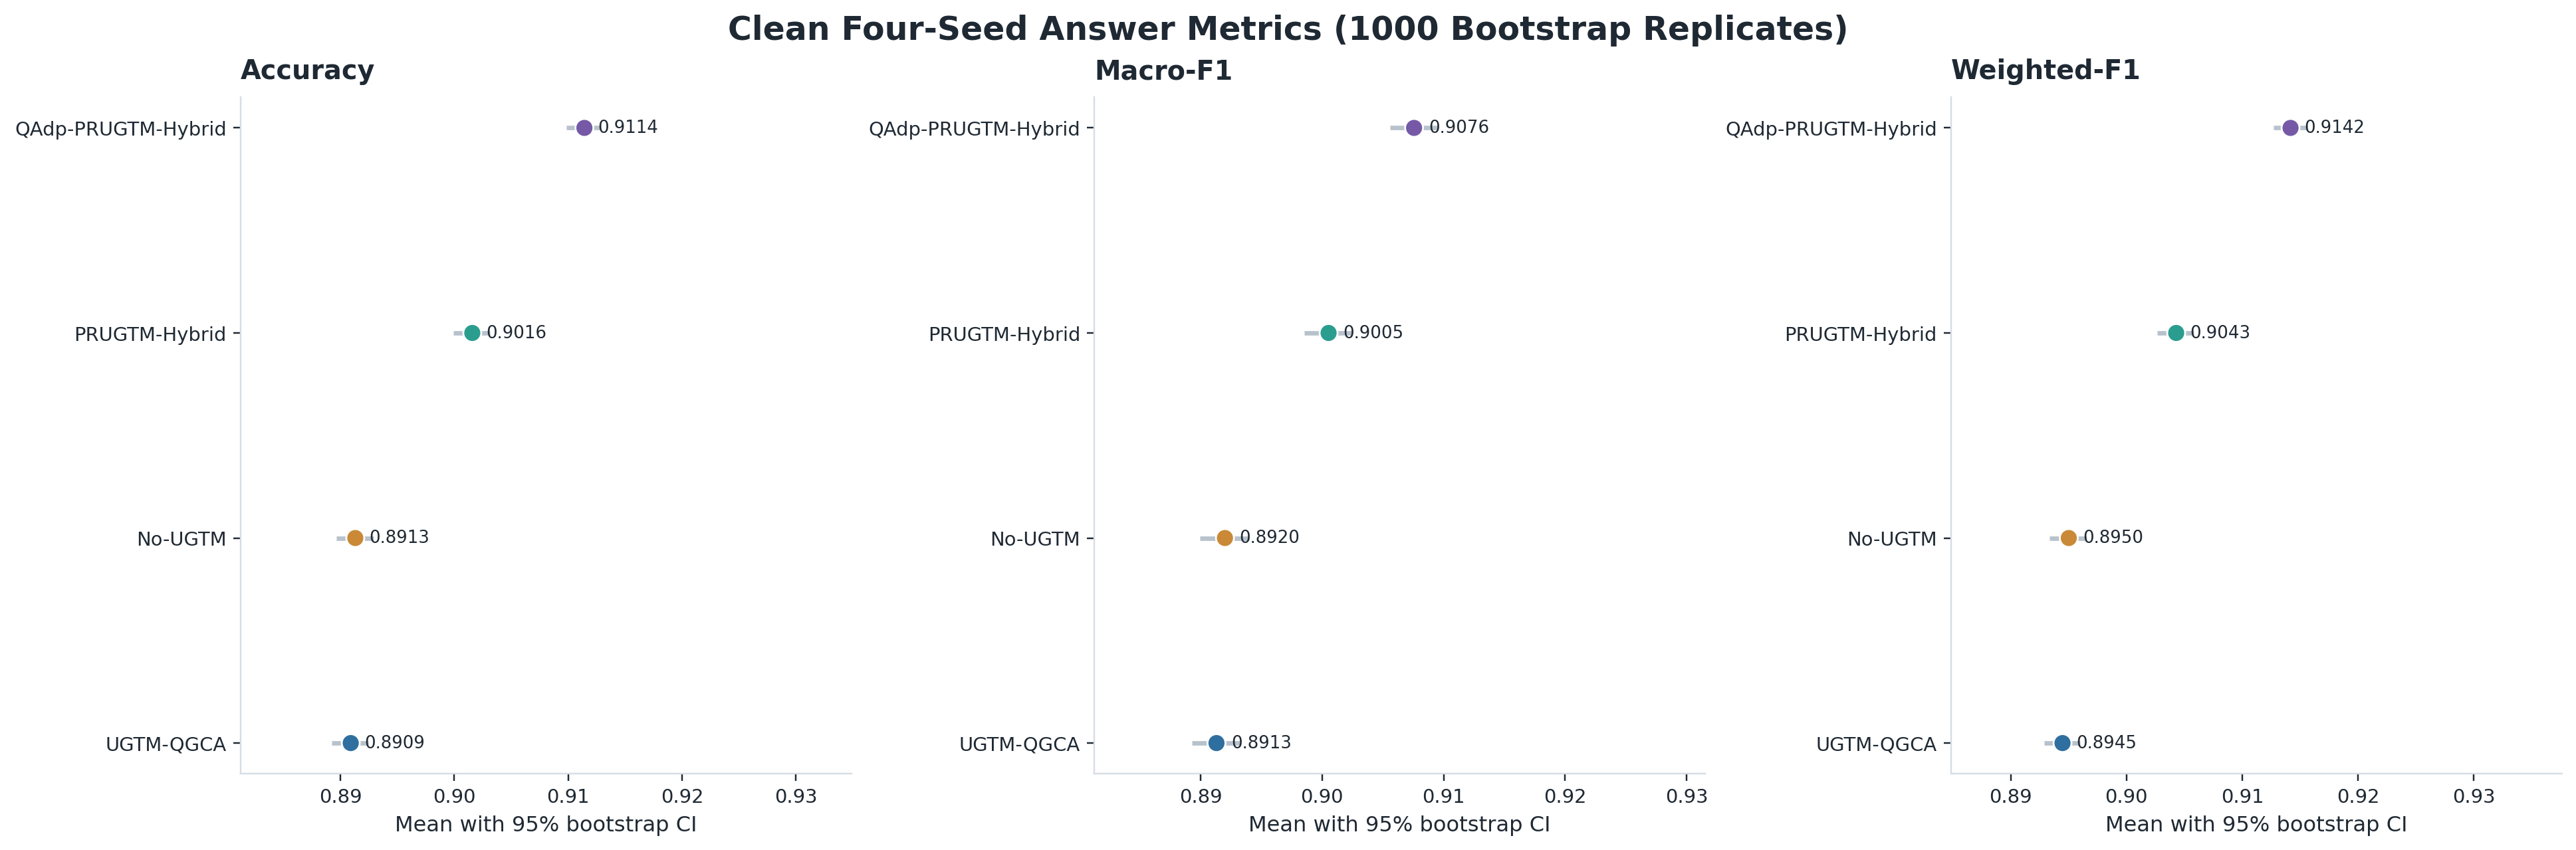

`phase5c_clean_metadata_four_seeds_bootstrap_ci_answer_metrics.png`

### Key QAdp Pairwise Difference CIs

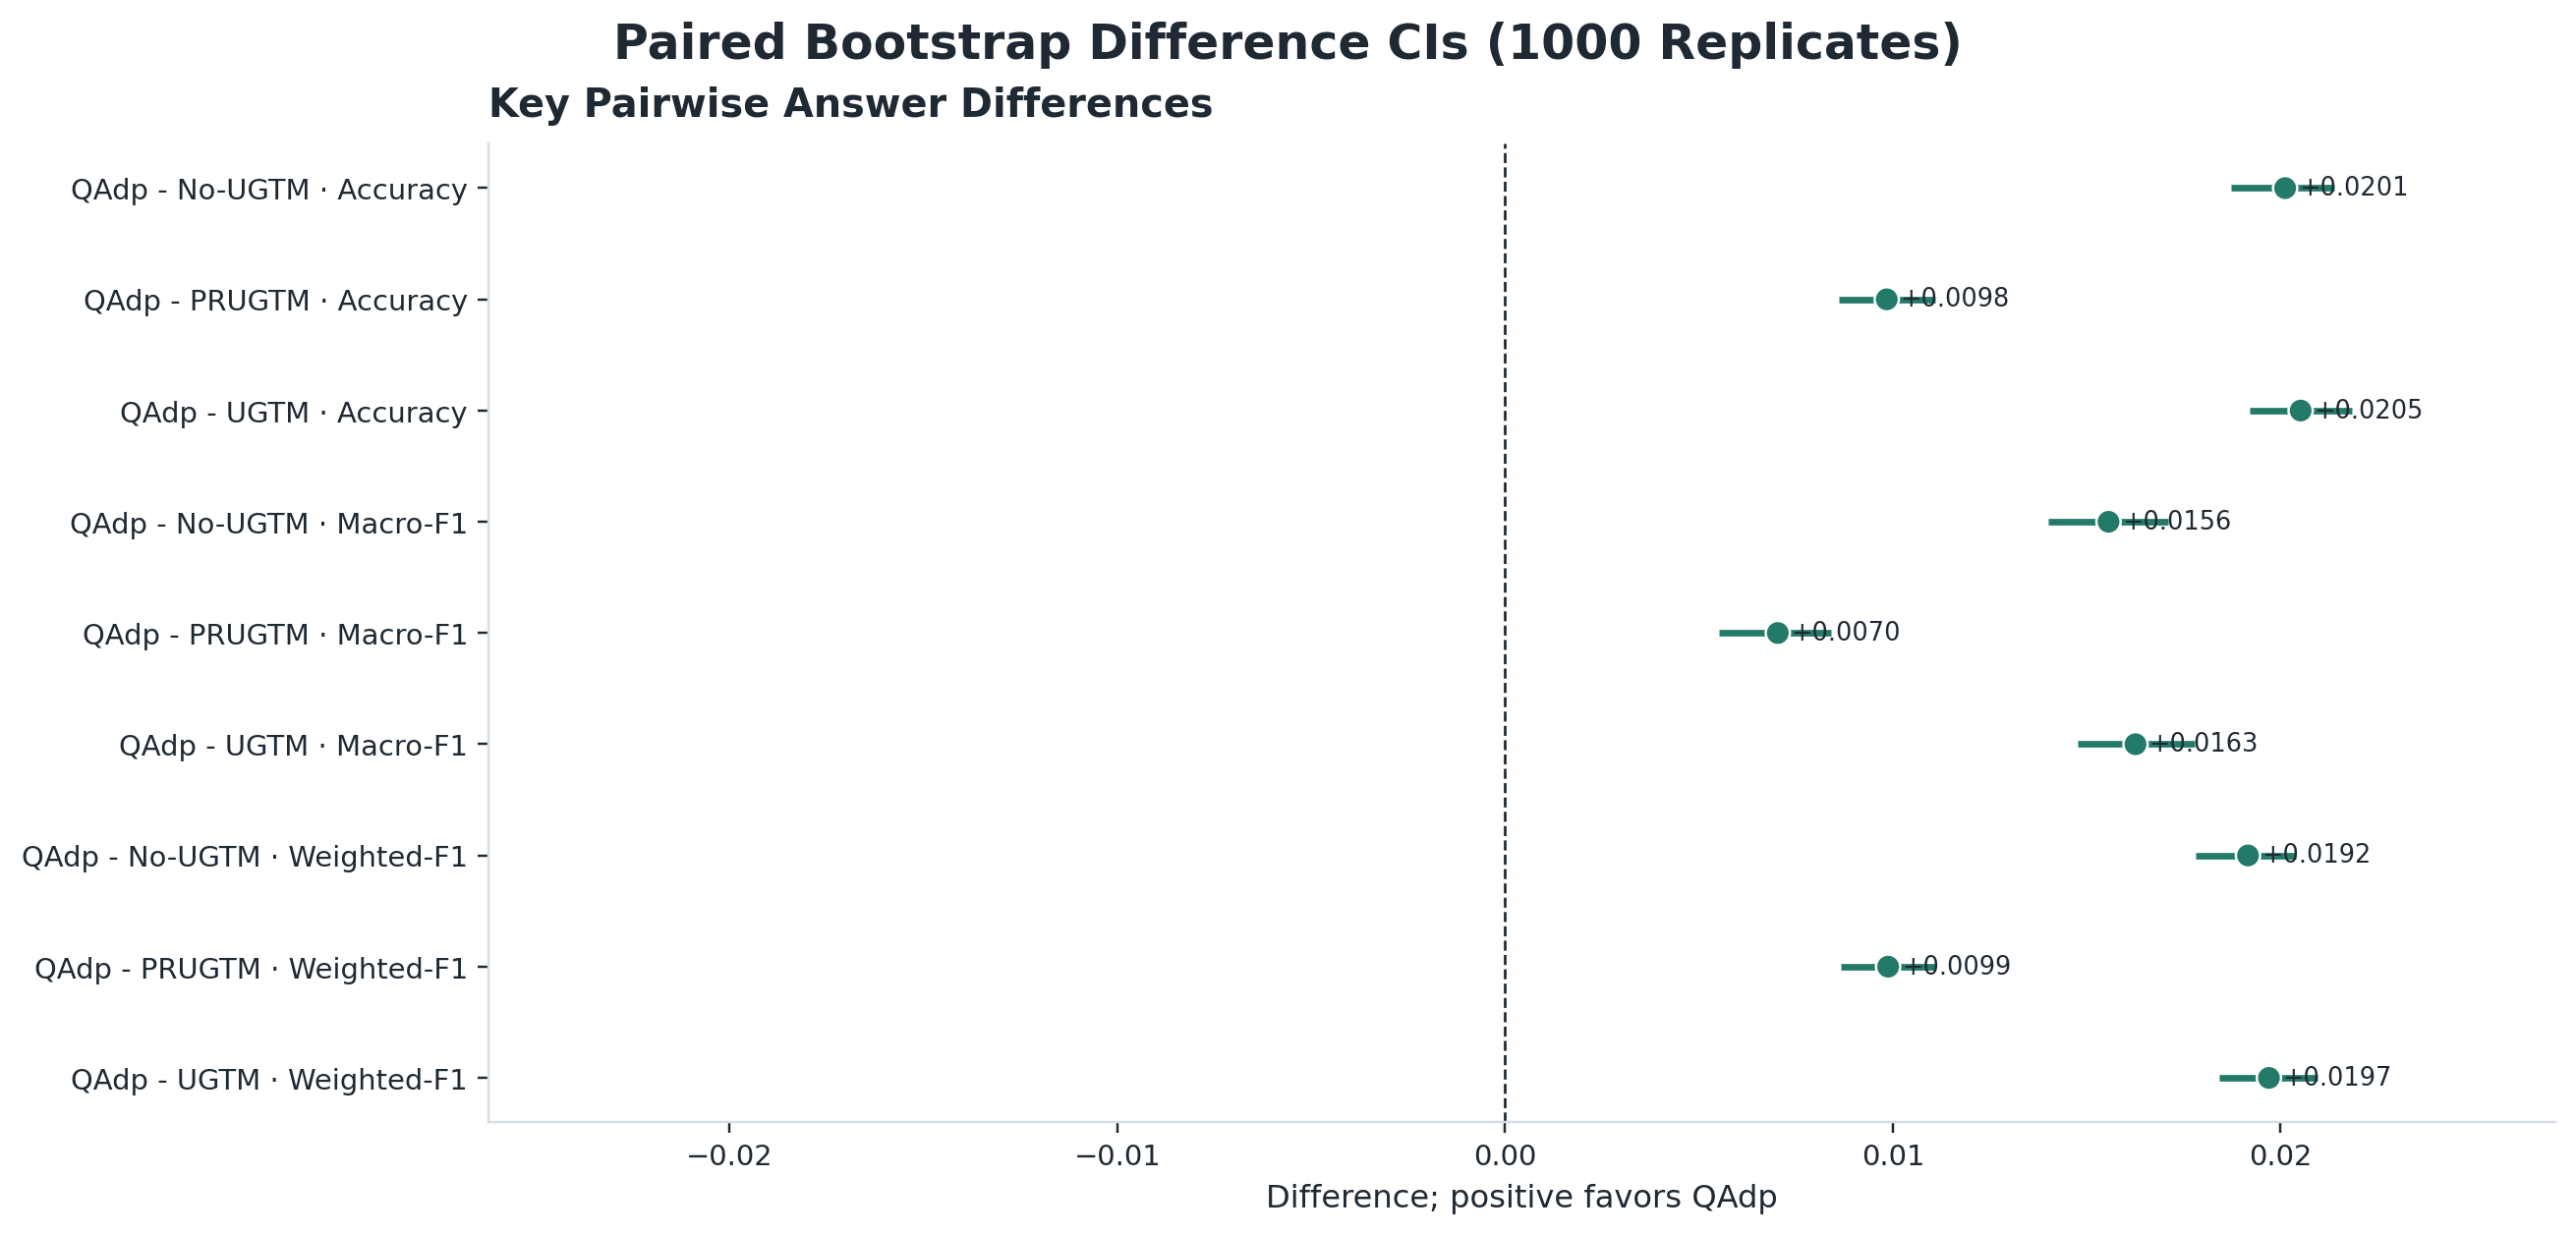

`phase5c_clean_metadata_four_seeds_bootstrap_pairwise_difference_ci.png`

### Focused Slice Macro-F1 Robustness

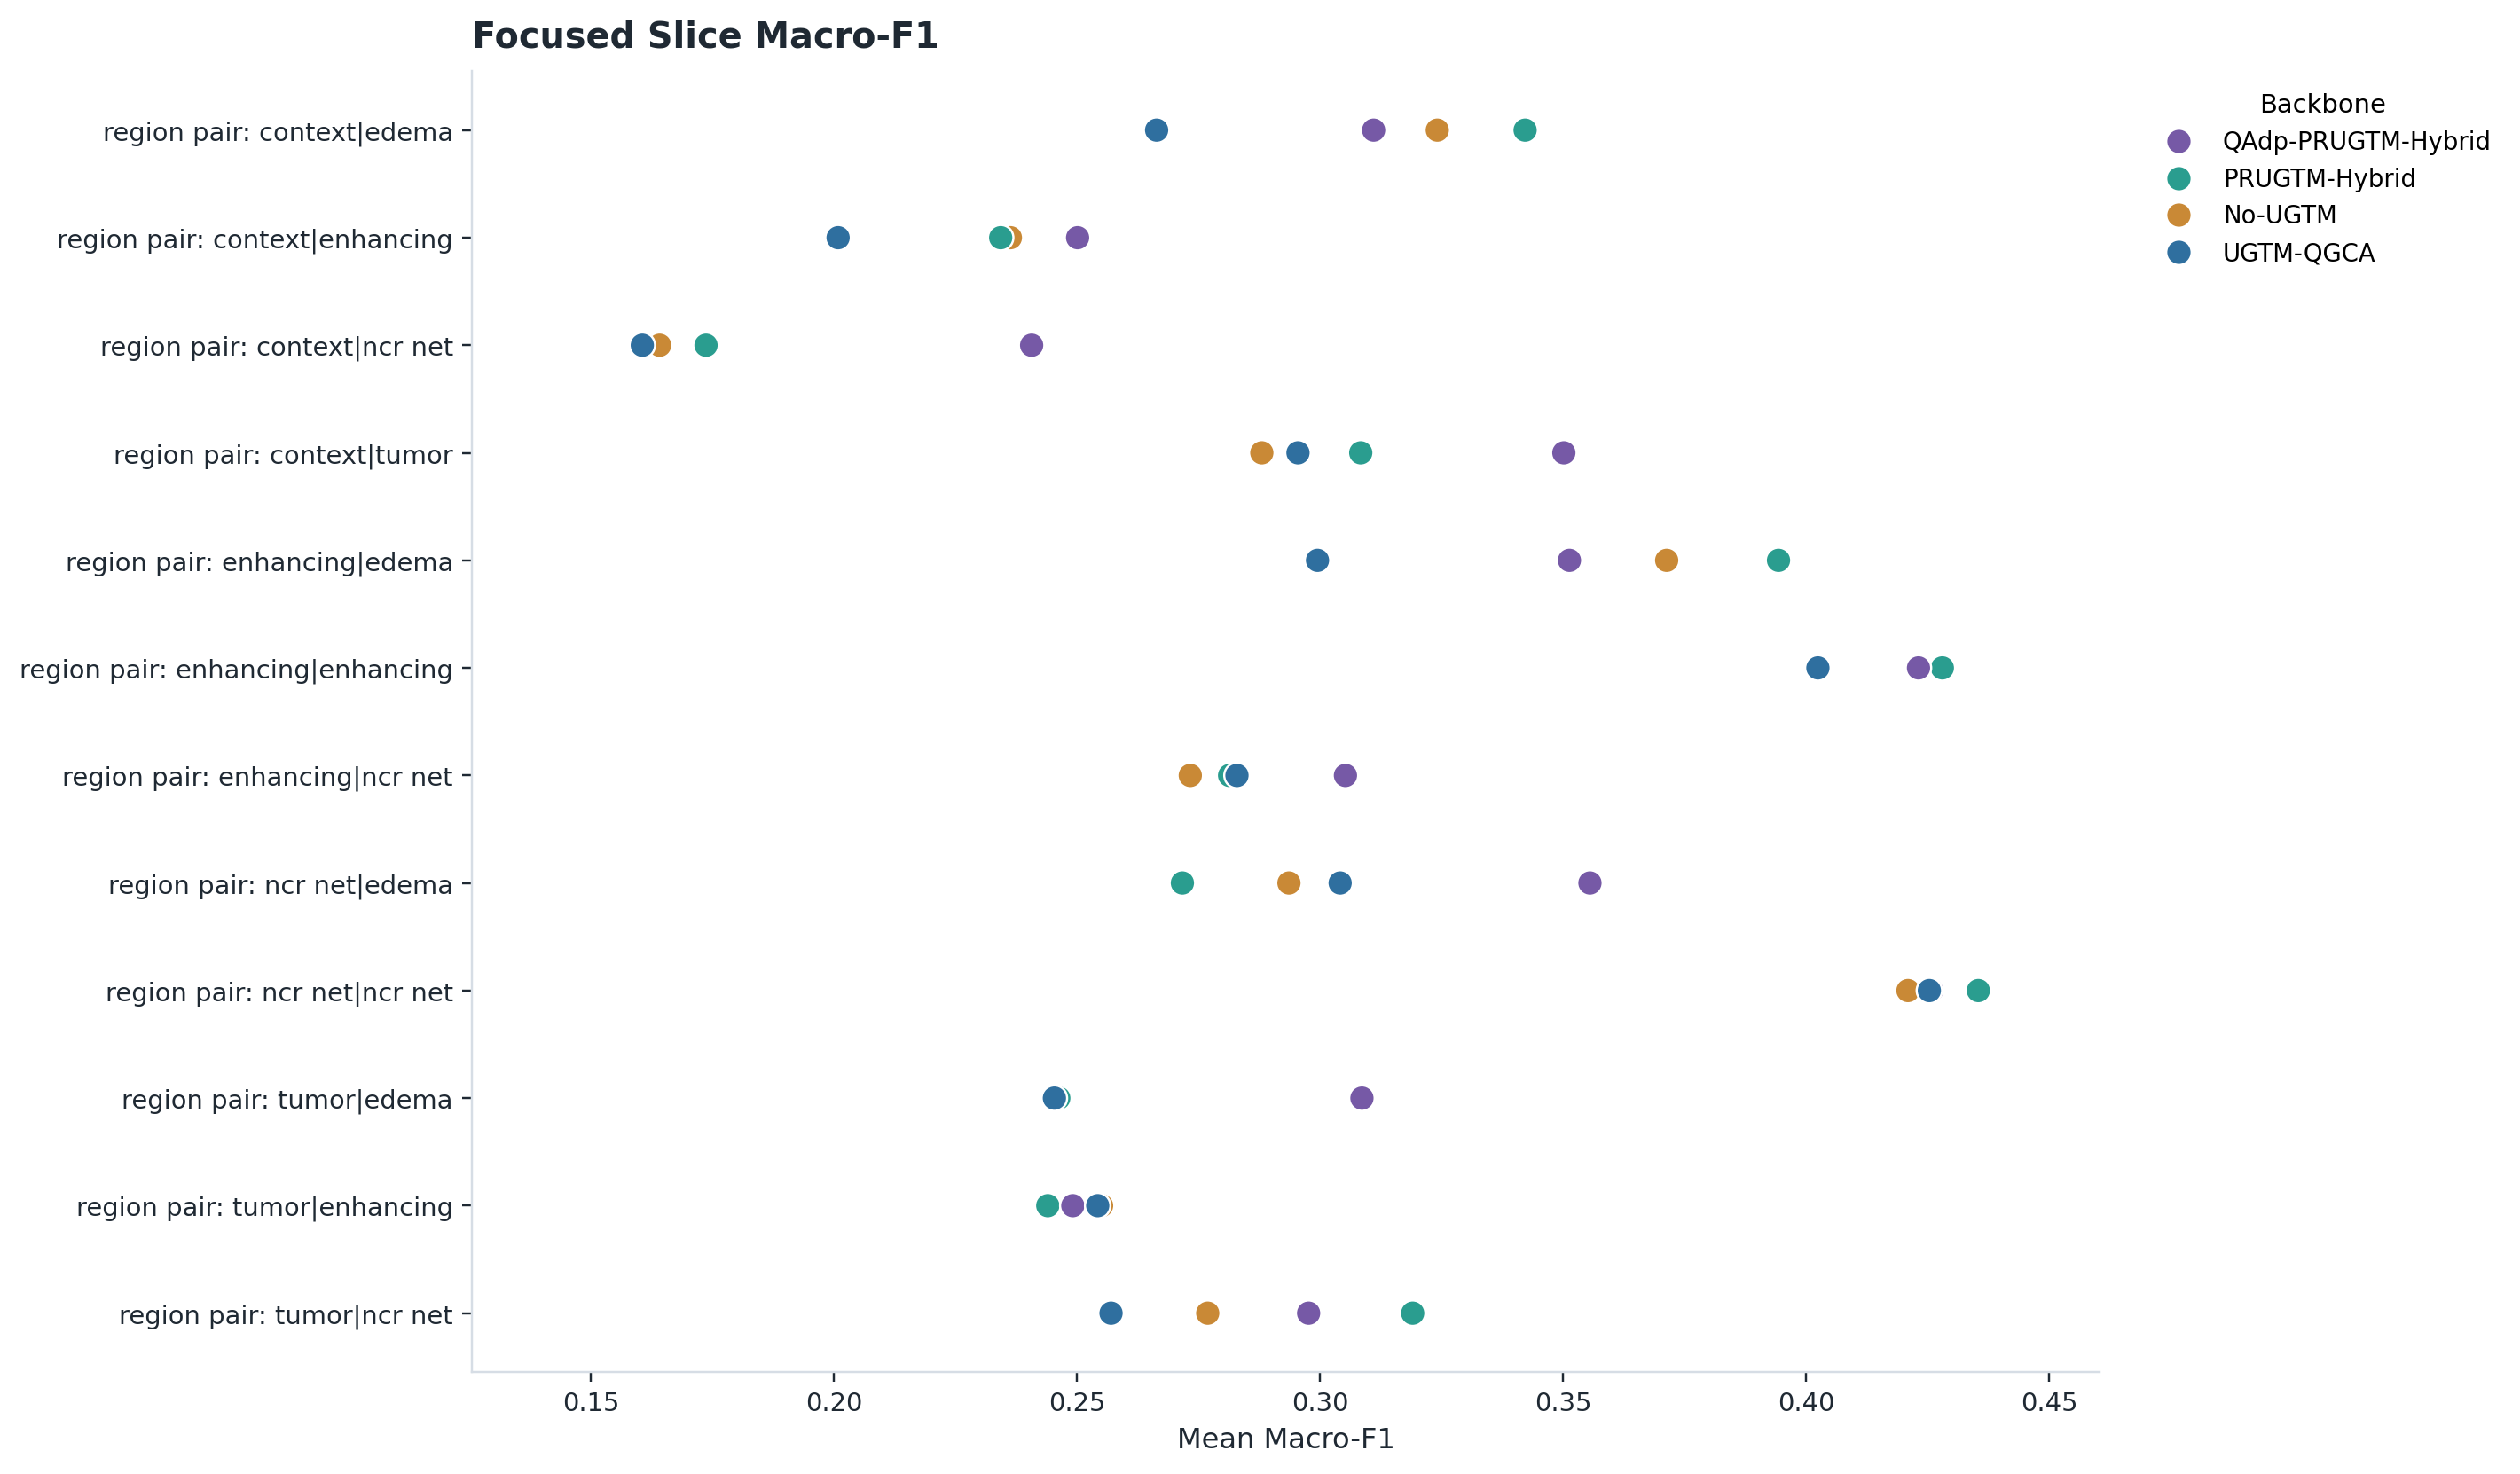

`phase5c_clean_metadata_four_seeds_slice_macro_f1_heatmap.png`

### Raw to Q-CUR ECE Gain

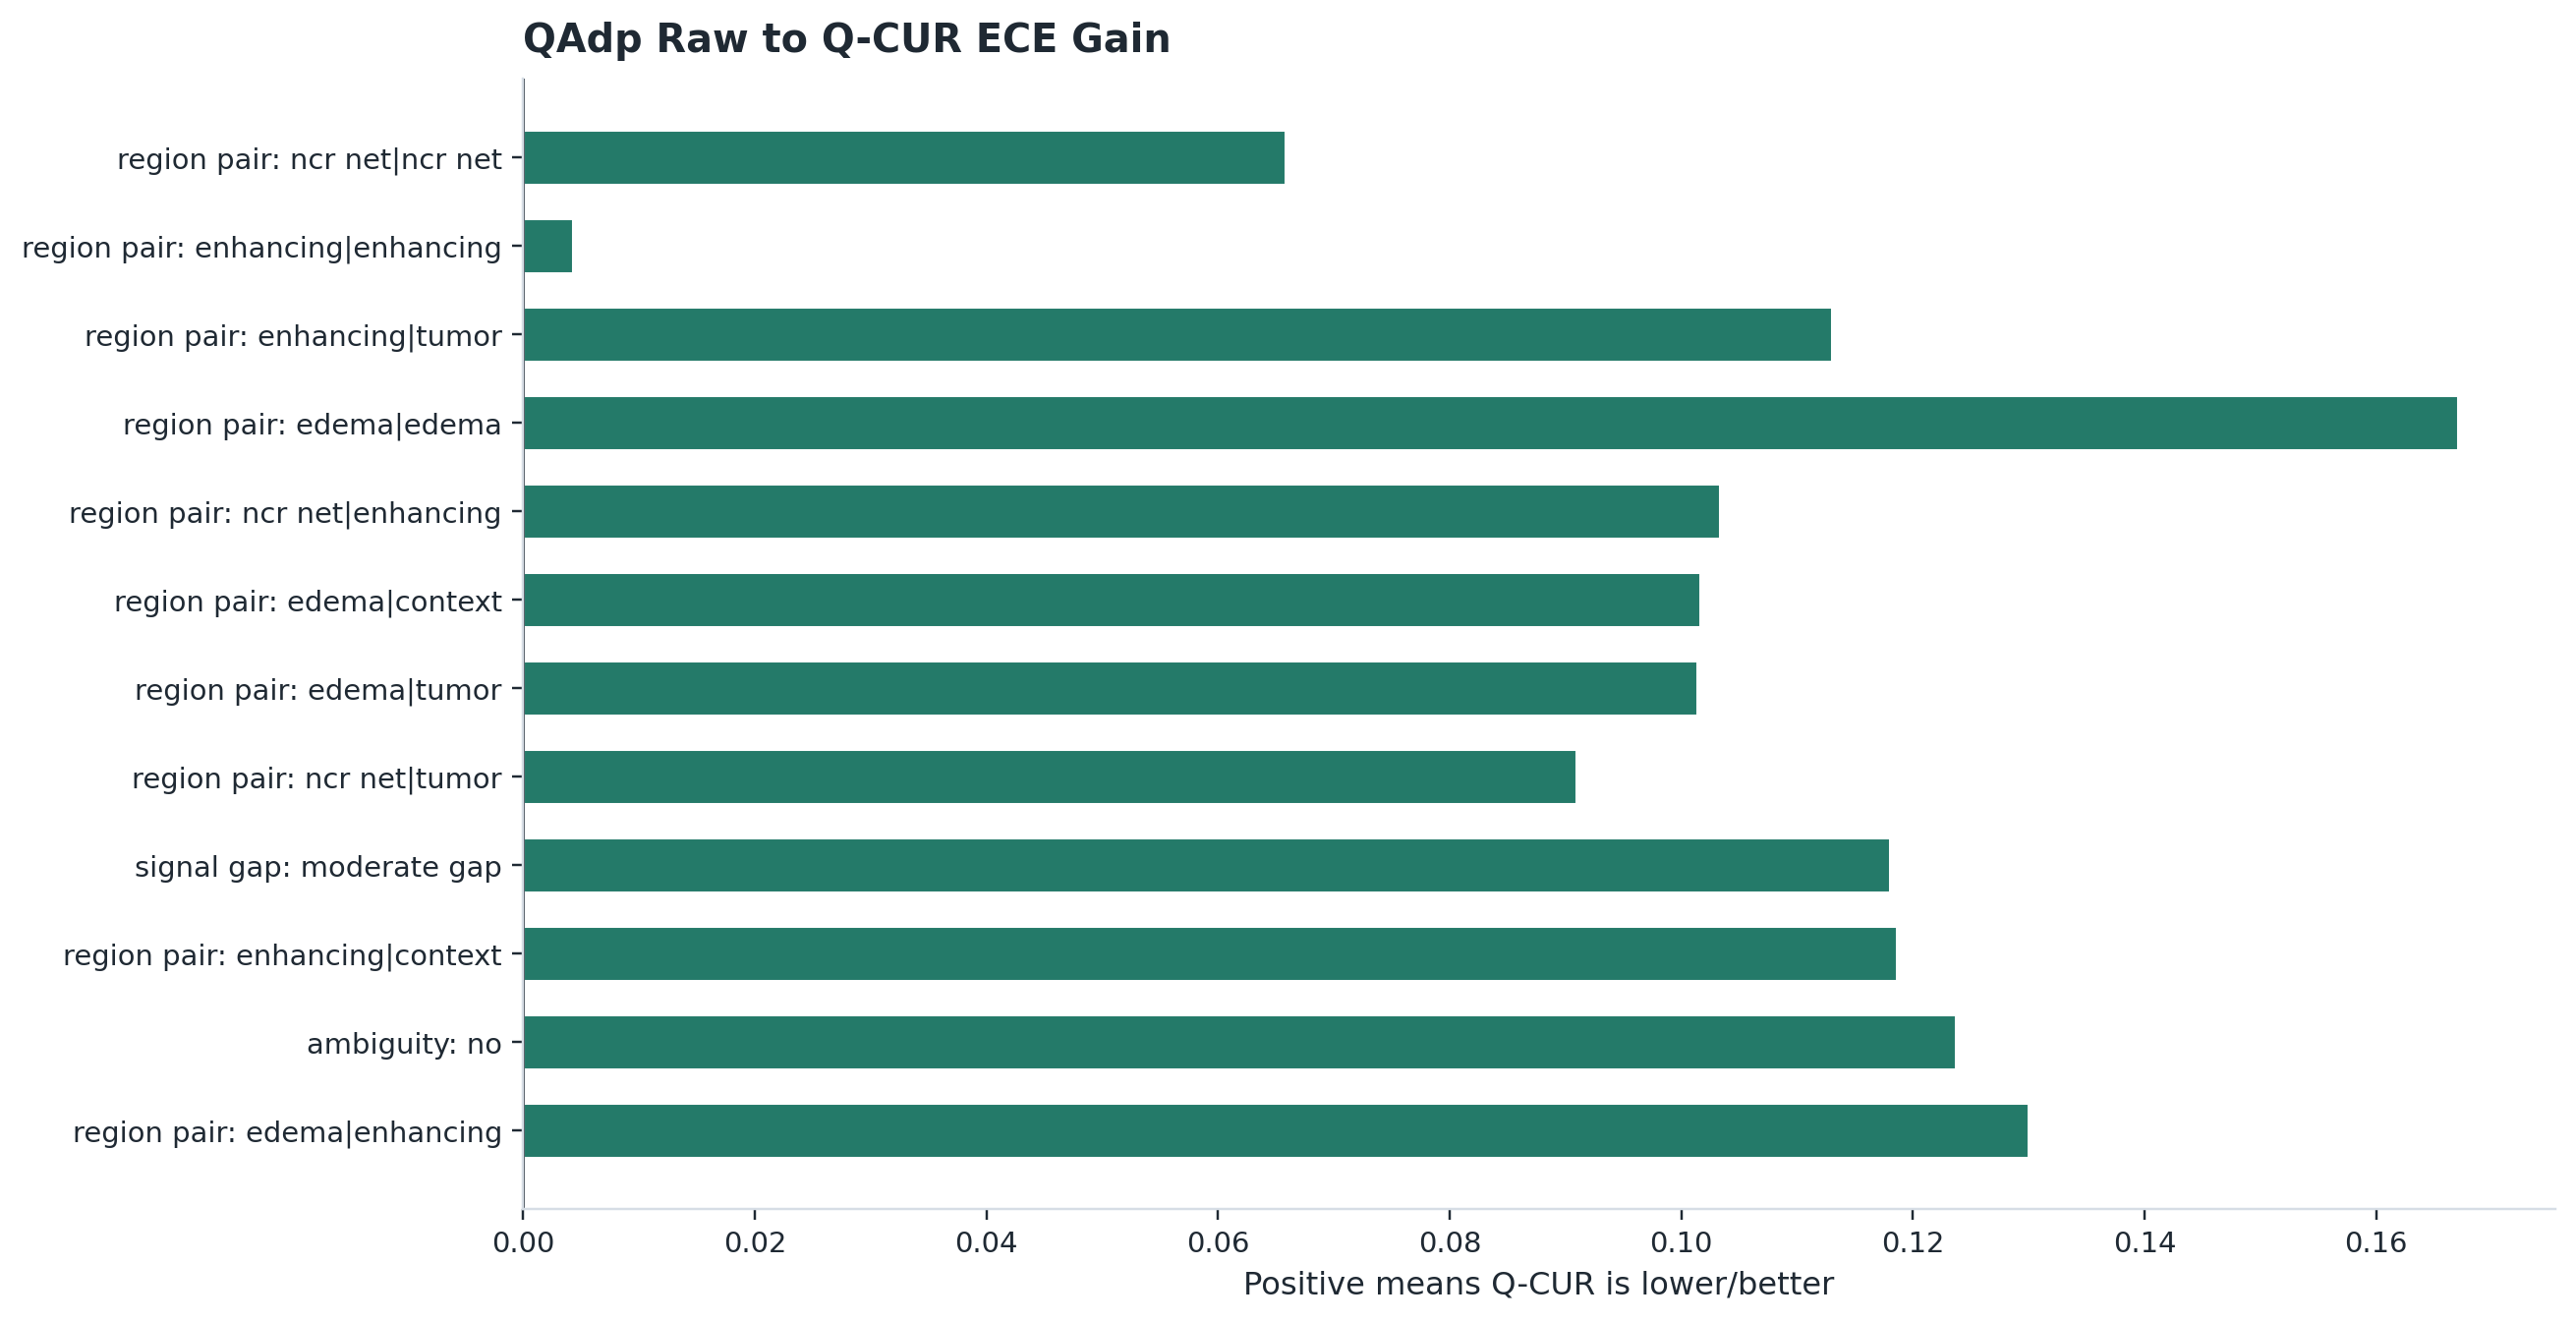

`phase5c_clean_metadata_four_seeds_slice_ece_qcur_gain_heatmap.png`

### Raw to Q-CUR Brier Gain

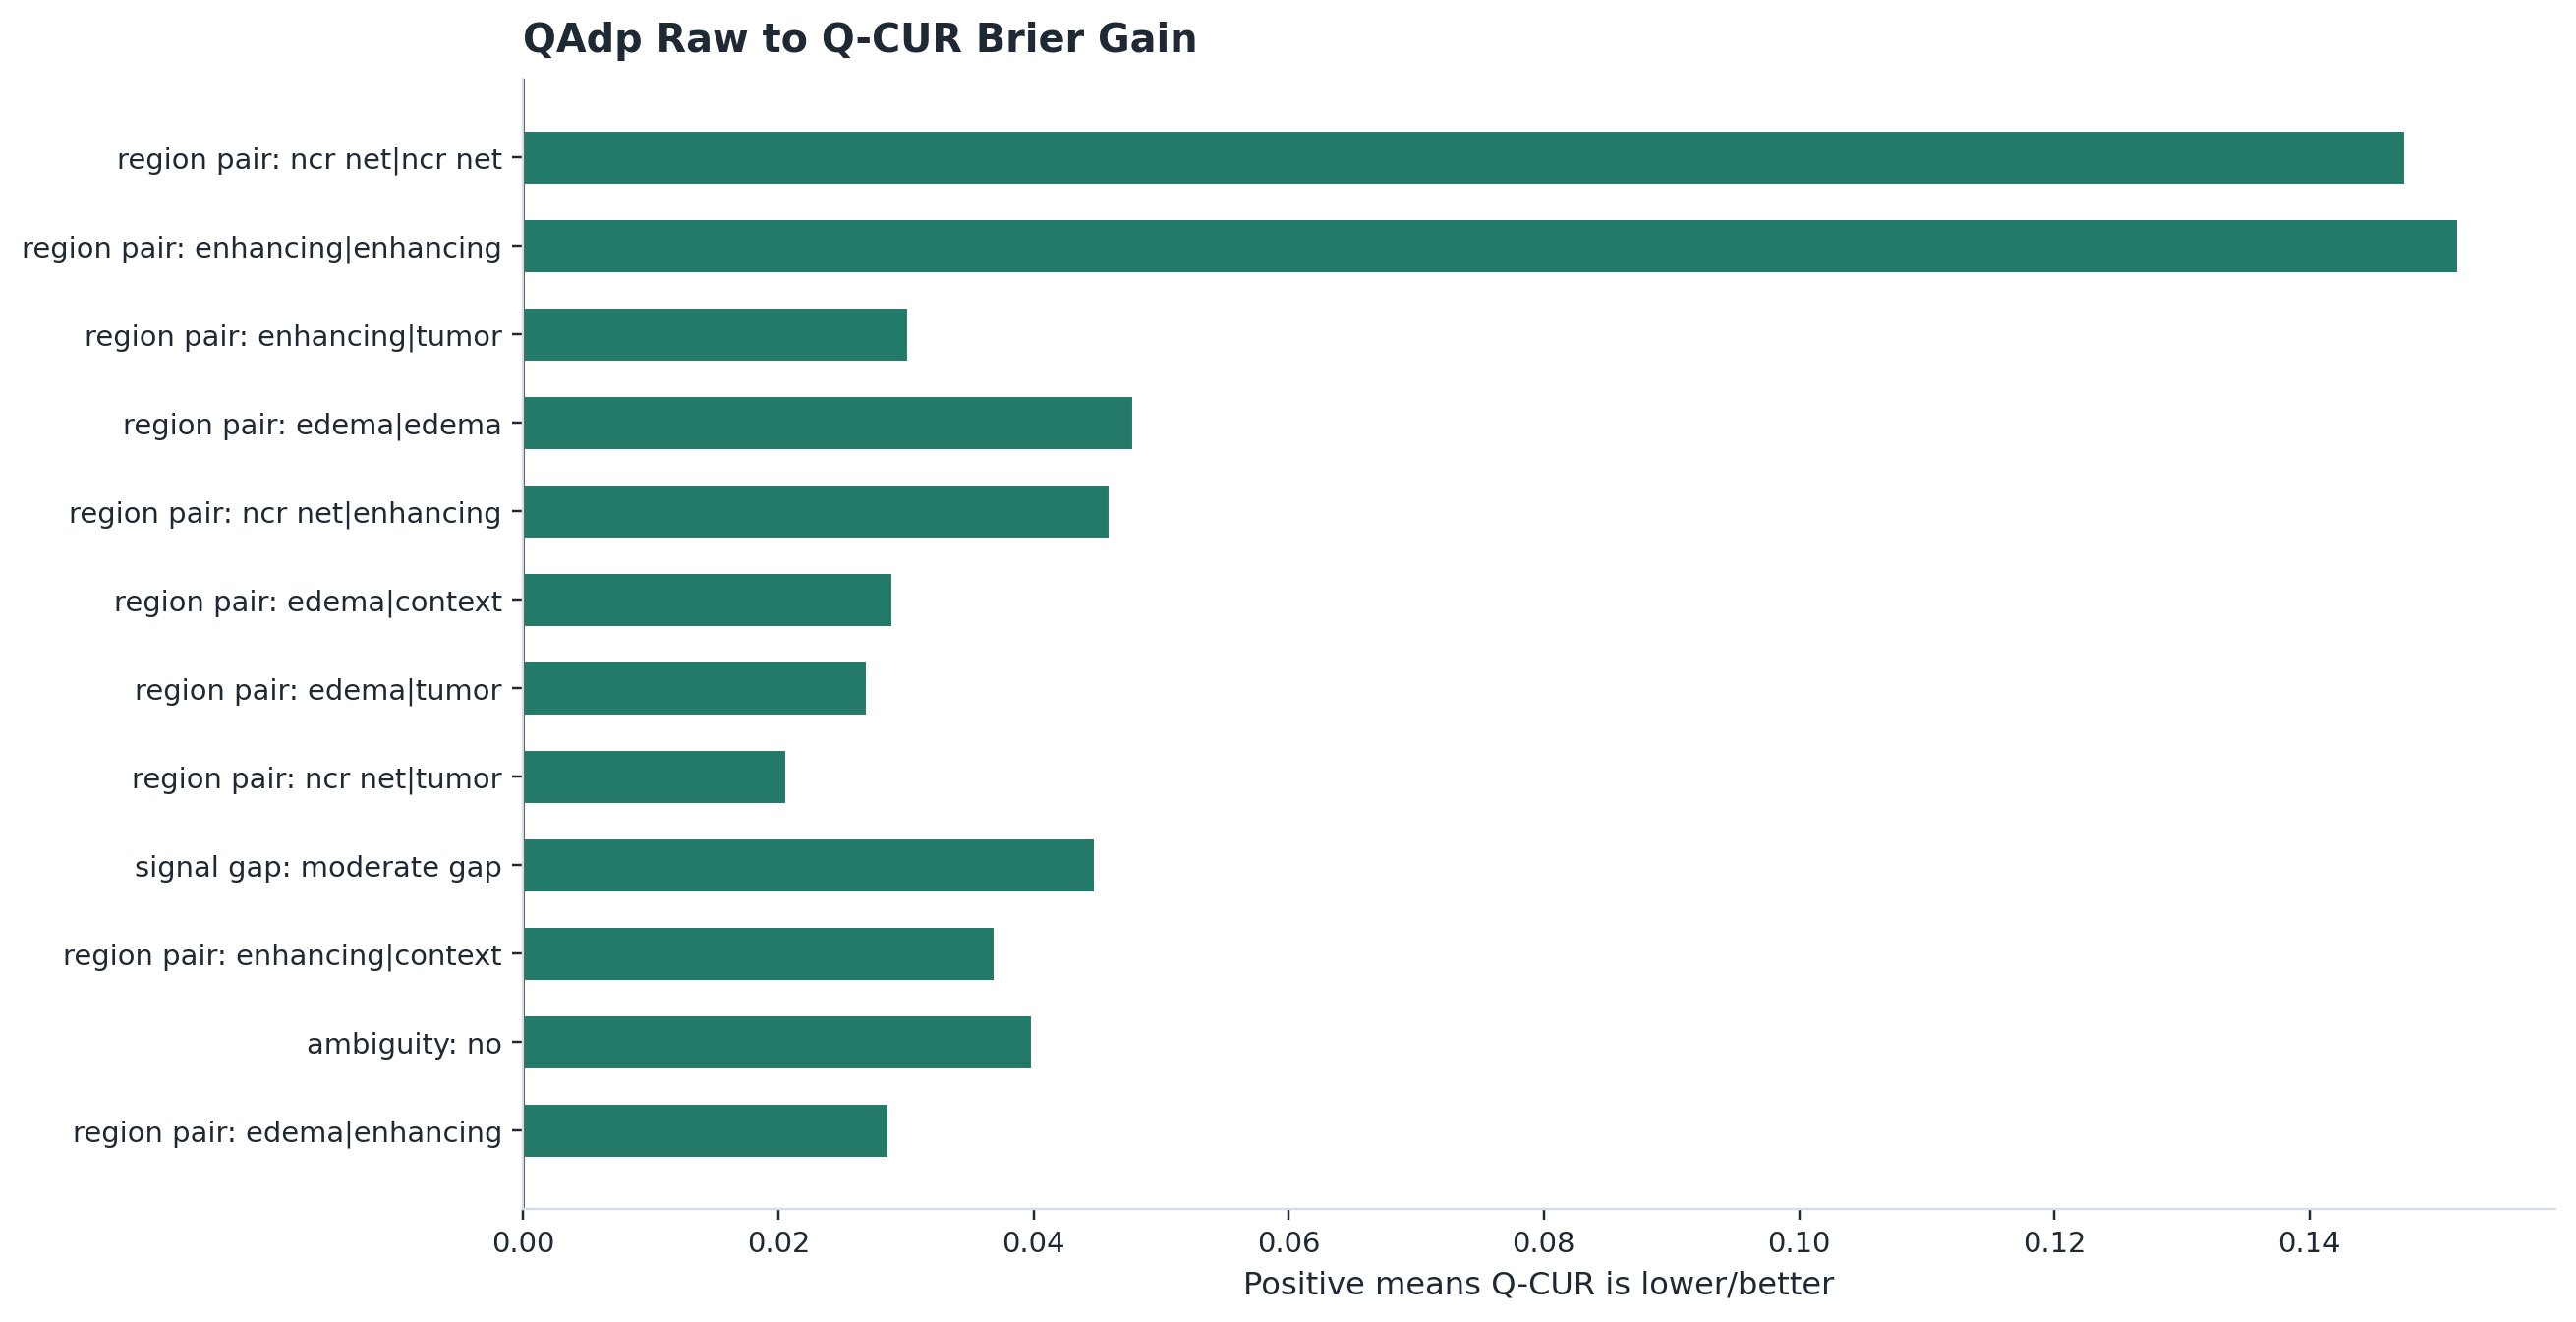

`phase5c_clean_metadata_four_seeds_slice_brier_qcur_gain_heatmap.png`

### Raw to Q-CUR NLL Gain

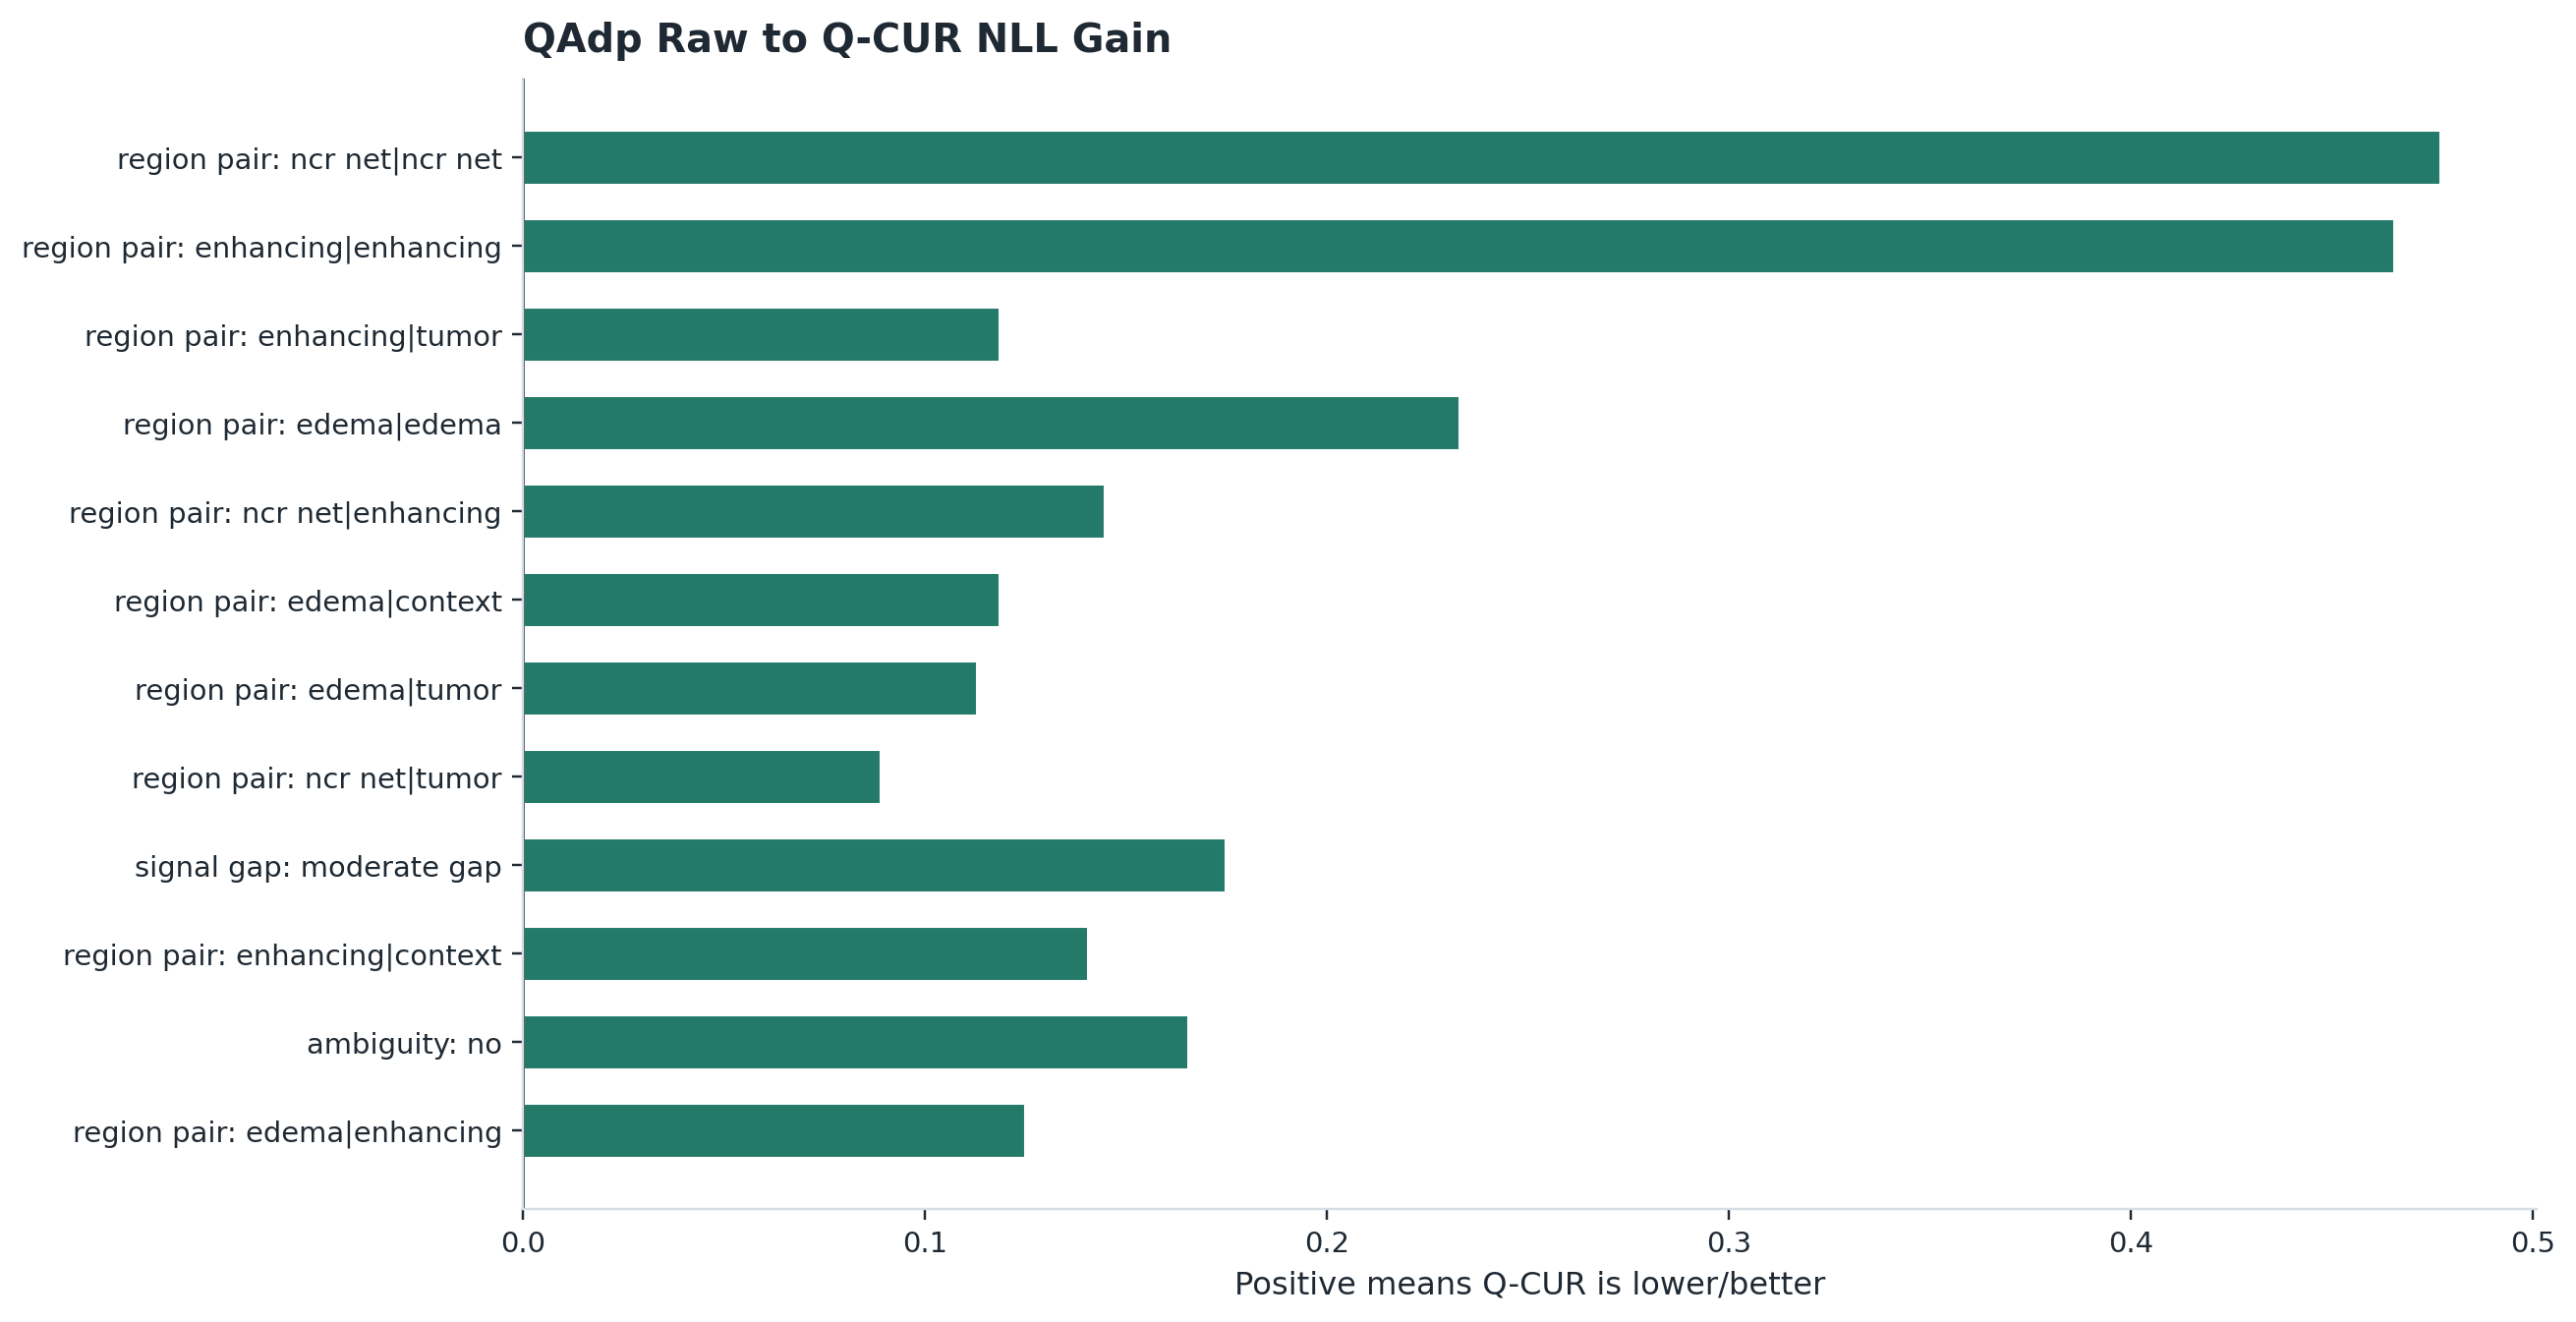

`phase5c_clean_metadata_four_seeds_slice_nll_qcur_gain_heatmap.png`

### Raw to Q-CUR AURC Gain

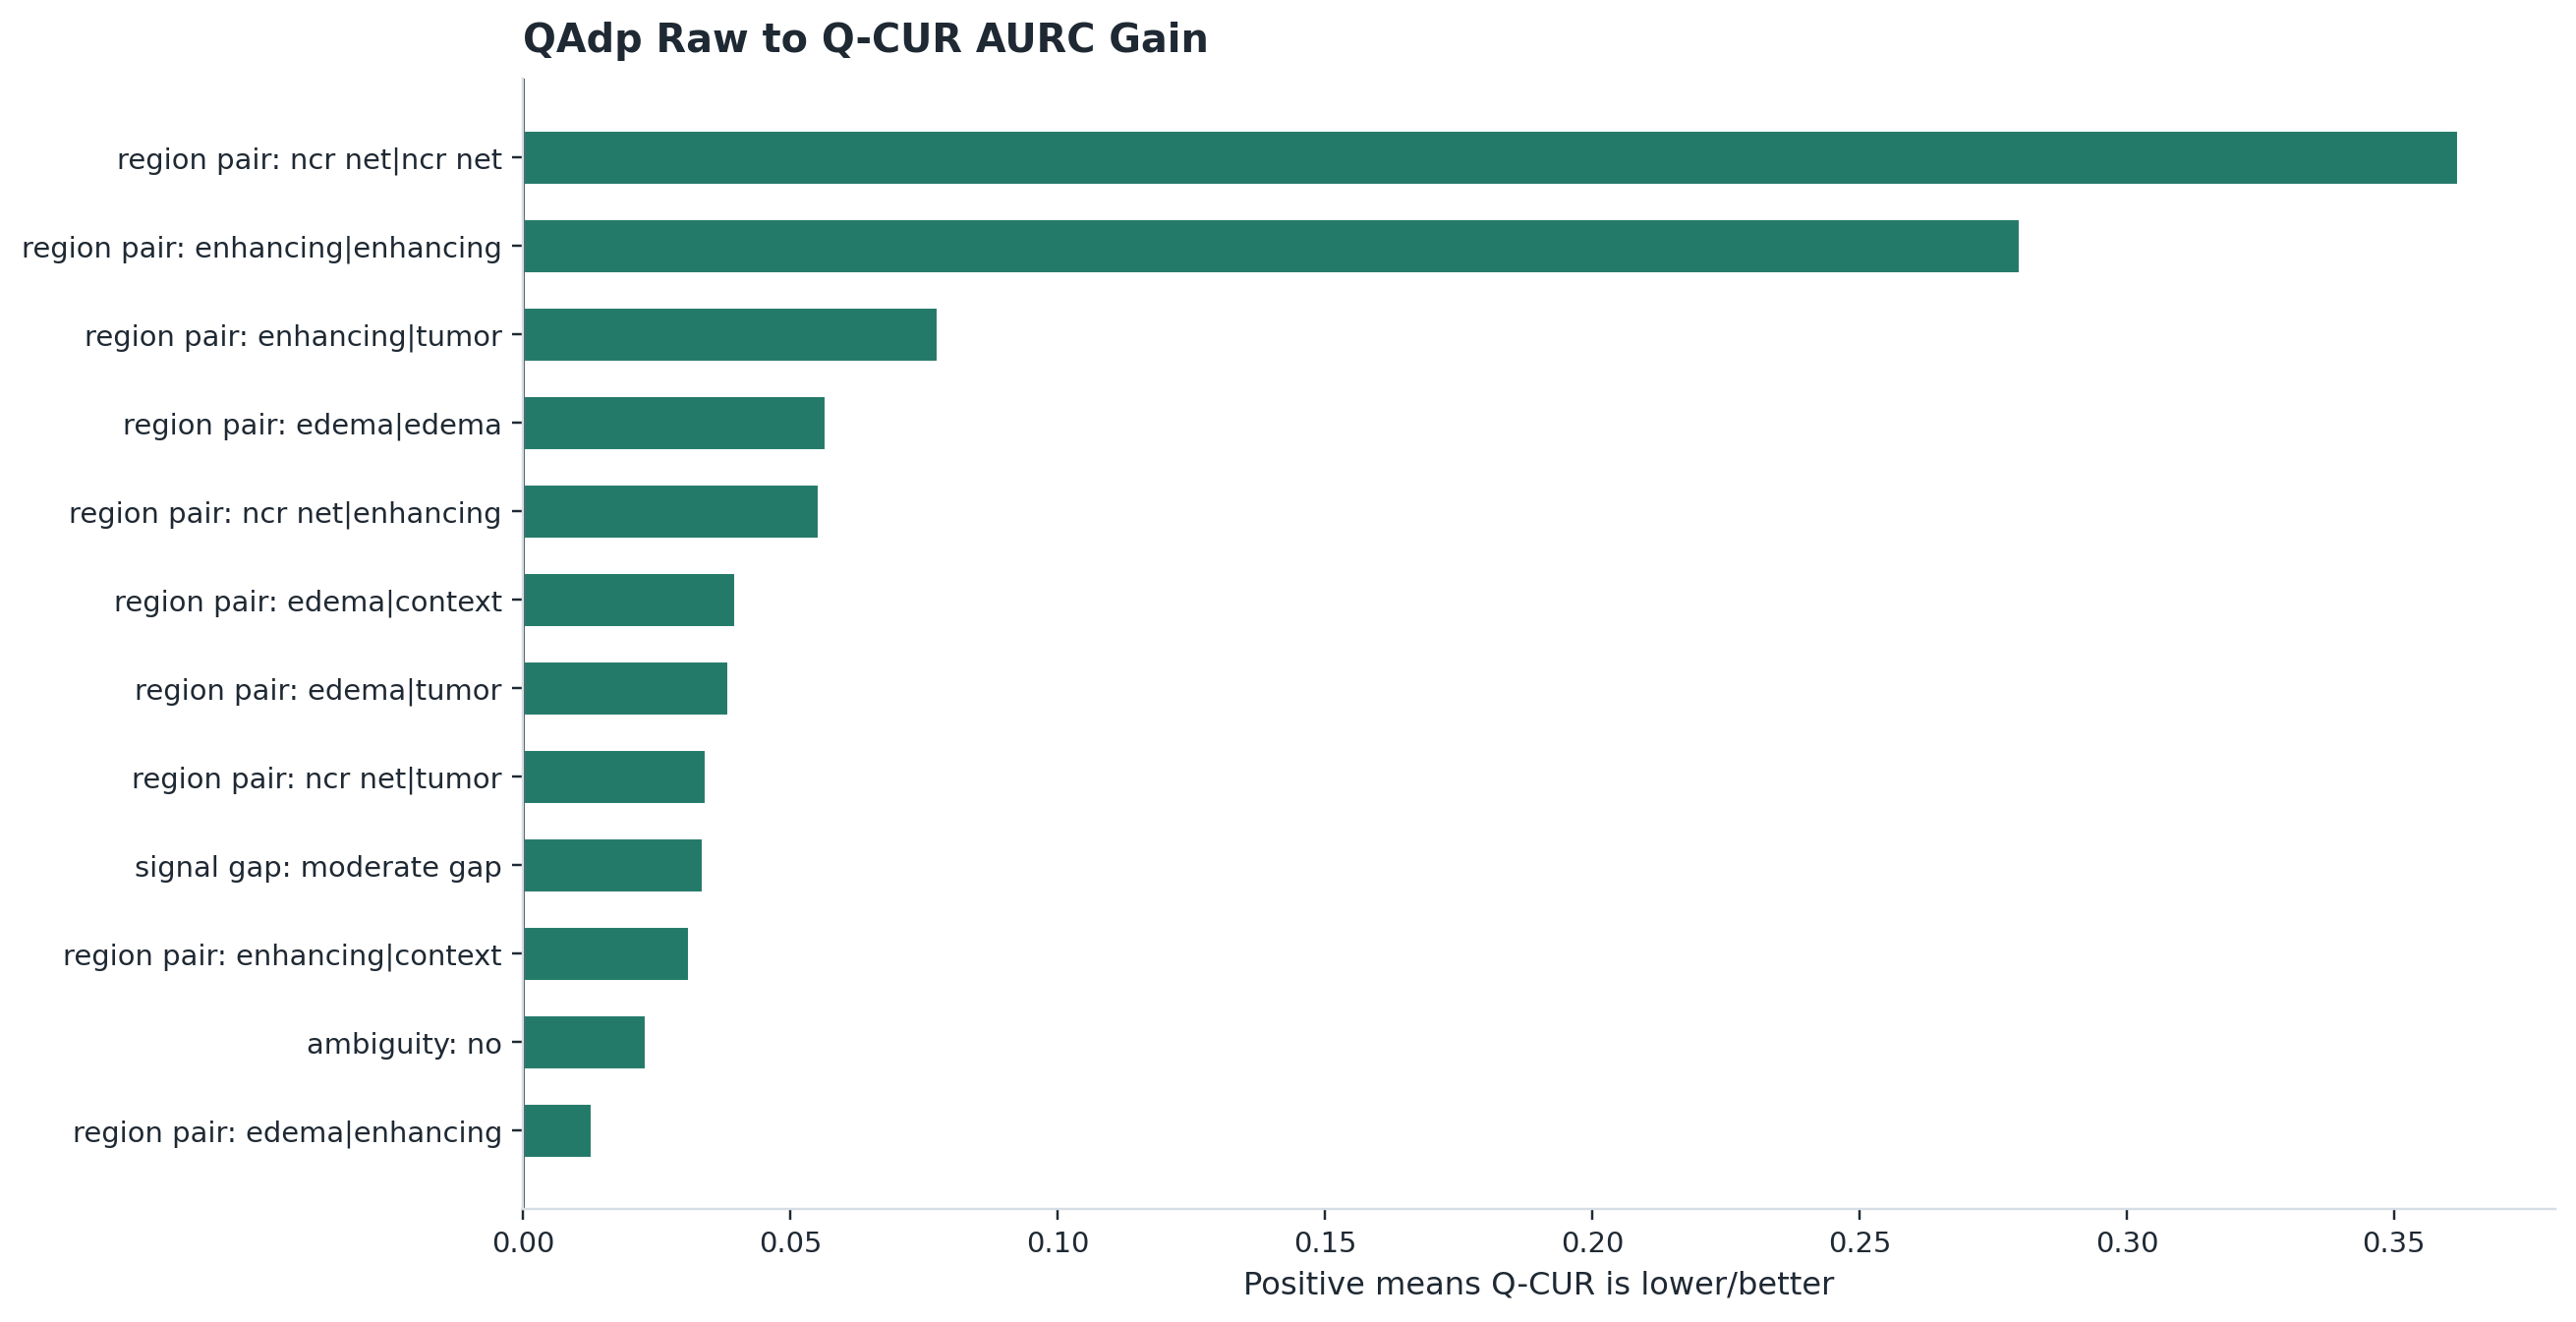

`phase5c_clean_metadata_four_seeds_slice_aurc_qcur_gain_heatmap.png`

### Reviewer Summary Dashboard

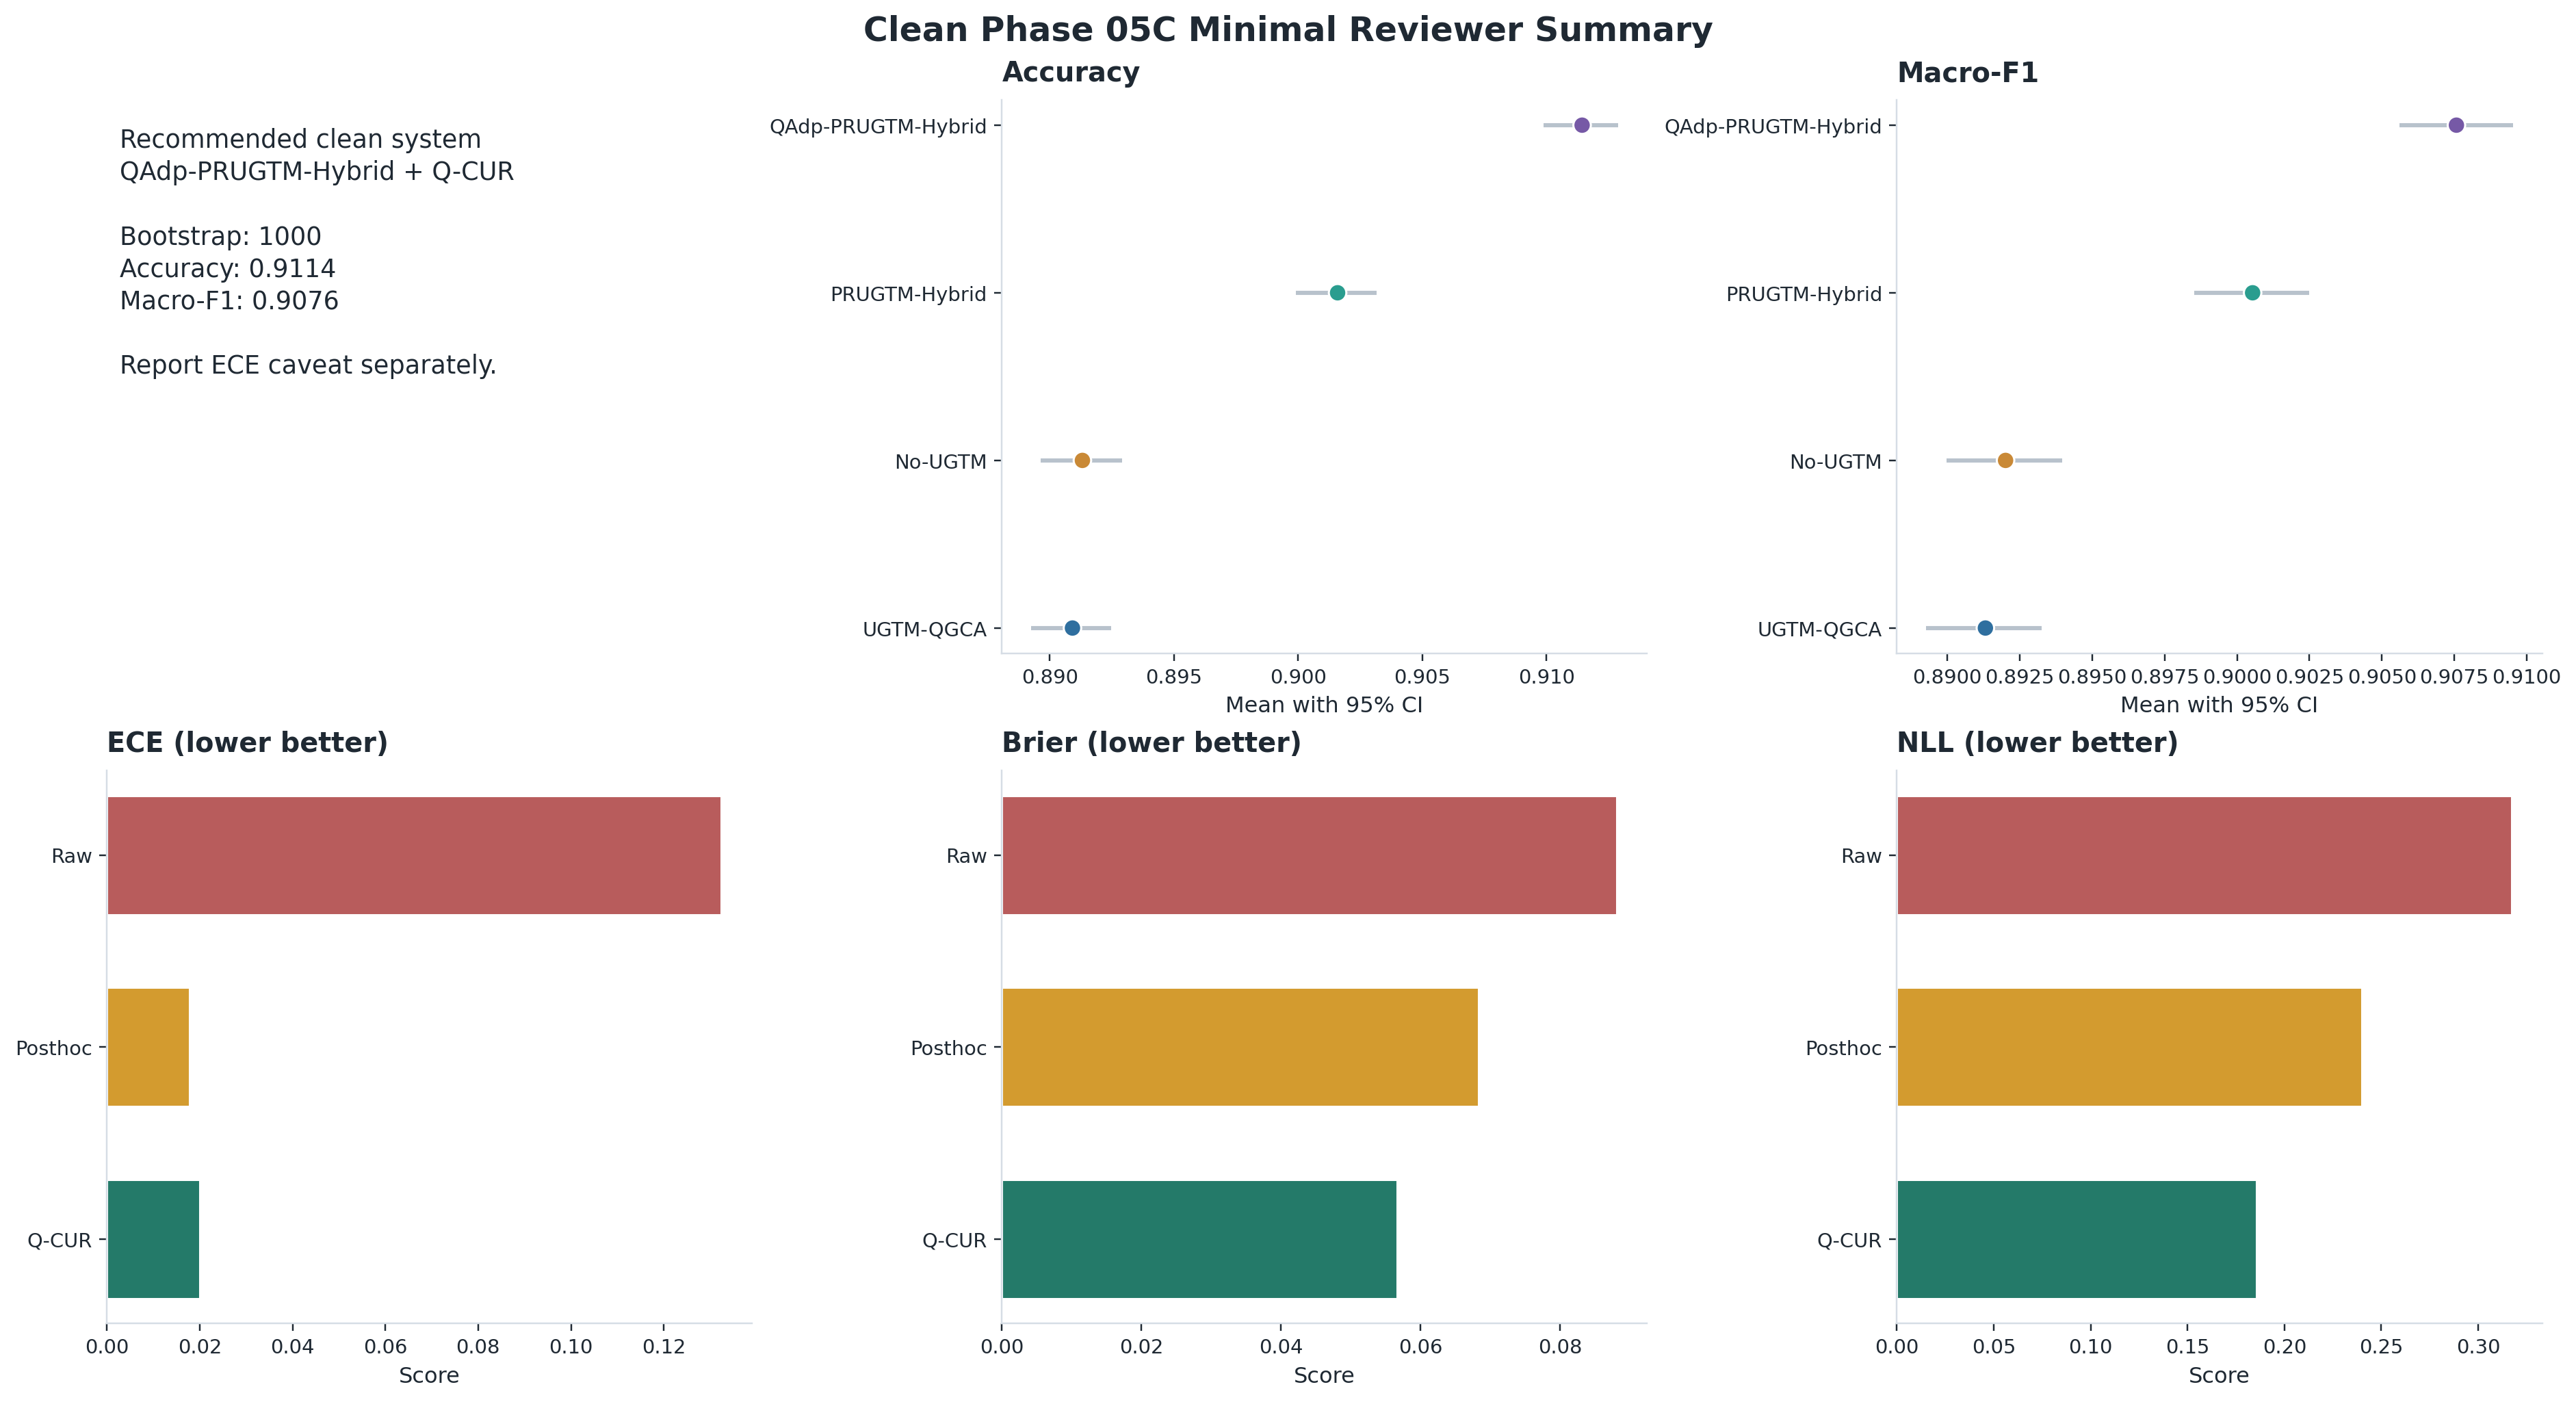

`phase5c_clean_metadata_four_seeds_reviewer_summary_dashboard.png`

In [14]:
from IPython.display import Image, Markdown, display

FINAL_CURRENT_RUN_FIGURE_ORDER = [
    ("Answer Metrics With 95% Bootstrap CIs", BOOTSTRAP_ANSWER_FIG_PATH),
    ("Key QAdp Pairwise Difference CIs", BOOTSTRAP_PAIRWISE_FIG_PATH),
    ("Focused Slice Macro-F1 Robustness", SLICE_MACRO_F1_FIG_PATH),
    ("Raw to Q-CUR ECE Gain", SLICE_ECE_GAIN_FIG_PATH),
    ("Raw to Q-CUR Brier Gain", SLICE_BRIER_GAIN_FIG_PATH),
    ("Raw to Q-CUR NLL Gain", SLICE_NLL_GAIN_FIG_PATH),
    ("Raw to Q-CUR AURC Gain", SLICE_AURC_GAIN_FIG_PATH),
    ("Reviewer Summary Dashboard", REVIEWER_DASHBOARD_FIG_PATH),
]

display(Markdown(f"## Final Reviewer Figures ({N_BOOTSTRAP} Bootstrap Replicates)"))
display(Markdown(f"Source folder: `{FIGURES_DIR}`"))

for title, figure_path in FINAL_CURRENT_RUN_FIGURE_ORDER:
    display(Markdown(f"### {title}"))
    if figure_path.exists():
        display(Image(filename=str(figure_path), width=1150))
        display(Markdown(f"`{figure_path.name}`"))
    else:
        display(Markdown(f"**Missing figure:** `{figure_path}`"))


# Quick Inspect Clean Phase 05C Artifacts

In [15]:
print("Clean Phase 05C output files:")
for path in sorted(PHASE5C_DIR.rglob("*")):
    if path.is_file():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"{str(path.relative_to(PHASE5C_DIR)):95s} {size_mb:9.2f} MB")

print()
print("Bootstrap backend used:", backend_metadata)
print("Recommended clean system:", final_report["paper_safe_interpretation"]["recommended_system"])
print("Paper-safe claim:", final_report["paper_safe_interpretation"]["answer_claim"])

Clean Phase 05C output files:
done/phase5c_clean_metadata_four_seeds_complete.json                                                 0.00 MB
figures/phase5c_clean_metadata_four_seeds_bootstrap_ci_answer_metrics.png                            0.13 MB
figures/phase5c_clean_metadata_four_seeds_bootstrap_pairwise_difference_ci.png                       0.17 MB
figures/phase5c_clean_metadata_four_seeds_reviewer_summary_dashboard.png                             0.20 MB
figures/phase5c_clean_metadata_four_seeds_slice_aurc_qcur_gain_heatmap.png                           0.13 MB
figures/phase5c_clean_metadata_four_seeds_slice_brier_qcur_gain_heatmap.png                          0.13 MB
figures/phase5c_clean_metadata_four_seeds_slice_ece_qcur_gain_heatmap.png                            0.13 MB
figures/phase5c_clean_metadata_four_seeds_slice_macro_f1_heatmap.png                                 0.18 MB
figures/phase5c_clean_metadata_four_seeds_slice_nll_qcur_gain_heatmap.png                         

# Regenerate minimal final figures for both Boot1000 and Boot2000 from saved CSVs only.
# Does NOT rerun bootstrap.

In [3]:
from pathlib import Path
import os
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, Markdown, display

def running_in_colab() -> bool:
    try:
        import google.colab
        return True
    except Exception:
        return False

if "PROJECT_DIR" not in globals():
    if running_in_colab():
        from google.colab import drive
#         drive.mount("/content/drive")
        # Updated project path to point to the new drive structure
PROJECT_DIR = PROJECT_ROOT
    else:
        PROJECT_DIR = Path.cwd()

if "PHASE5C_BASE_DIR" not in globals():
    # Corrected paths: phase_5/p5c_statistical_confidence_slice_robustness
    PHASE5C_BASE_DIR = PROJECT_DIR / "phase_5" / "p5c_statistical_confidence_slice_robustness"

BOOT_RUNS = {
    "Boot1000": {
        "folder": PHASE5C_BASE_DIR / "btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000",
        "n_bootstrap": 1000,
    },
    "Boot2000": {
        "folder": PHASE5C_BASE_DIR / "btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot2000",
        "n_bootstrap": 2000,
    },
}

PREFIX = "phase5c_clean_metadata_four_seeds"

FIGURE_FILES = {
    "answer": f"{PREFIX}_bootstrap_ci_answer_metrics.png",
    "pairwise": f"{PREFIX}_bootstrap_pairwise_difference_ci.png",
    "slice_macro": f"{PREFIX}_slice_macro_f1_heatmap.png",
    "ece_gain": f"{PREFIX}_slice_ece_qcur_gain_heatmap.png",
    "brier_gain": f"{PREFIX}_slice_brier_qcur_gain_heatmap.png",
    "nll_gain": f"{PREFIX}_slice_nll_qcur_gain_heatmap.png",
    "aurc_gain": f"{PREFIX}_slice_aurc_qcur_gain_heatmap.png",
    "reviewer": f"{PREFIX}_reviewer_summary_dashboard.png",
}

minimal_backbone_order = [
    "QAdp-PRUGTM-Hybrid",
    "PRUGTM-Hybrid",
    "No-UGTM",
    "UGTM-QGCA",
]

minimal_palette = {
    "QAdp-PRUGTM-Hybrid": "#247a69",
    "PRUGTM-Hybrid": "#3a86c8",
    "No-UGTM": "#b85c5c",
    "UGTM-QGCA": "#ca952e",
    "Raw": "#b85c5c",
    "Posthoc": "#ca952e",
    "Q-CUR": "#247a69",
    "ink": "#1e2229",
    "line": "#ccd4dc",
}

def clean_slice_label(slice_id: str) -> str:
    parts = str(slice_id).split("__")
    if len(parts) != 2:
        return str(slice_id)
    val = parts[1]
    return val.replace("_", " ").title()

def minimal_axis(ax, title: str, xlabel: str, ylabel: str):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8, color=minimal_palette["ink"])
    ax.set_xlabel(xlabel, fontsize=9.5, color=minimal_palette["ink"])
    ax.set_ylabel(ylabel, fontsize=9.5, color=minimal_palette["ink"])
    ax.tick_params(colors=minimal_palette["ink"], labelsize=8.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(minimal_palette["line"])
    ax.spines["bottom"].set_color(minimal_palette["line"])
    ax.grid(True, linestyle=":", alpha=0.4, color=minimal_palette["line"])

def regenerate_minimal_figures(run_name: str, run_spec: dict):
    folder = run_spec["folder"]
    n_bootstrap = run_spec["n_bootstrap"]

    boot_global_ci_path = folder / "tables" / f"{PREFIX}_bootstrap_ci_global_metrics.csv"
    pairwise_path = folder / "tables" / f"{PREFIX}_bootstrap_pairwise_differences.csv"
    key_slice_answer_path = folder / "tables" / f"{PREFIX}_key_slice_answer_comparison.csv"
    key_slice_qcur_gain_path = folder / "tables" / f"{PREFIX}_key_slice_qcur_gain_summary.csv"

    missing = [p for p in [boot_global_ci_path, pairwise_path, key_slice_answer_path, key_slice_qcur_gain_path] if not p.exists()]
    if missing:
        print(f"Skipping {run_name} due to missing tables: {[m.name for m in missing]}")
        return []

    bootstrap_global_ci_df = pd.read_csv(boot_global_ci_path)
    bootstrap_pairwise_df = pd.read_csv(pairwise_path)
    key_slice_answer_df = pd.read_csv(key_slice_answer_path)
    key_slice_qcur_gain_df = pd.read_csv(key_slice_qcur_gain_path)

    # Define absolute figure paths
    BOOTSTRAP_ANSWER_FIG_PATH = folder / "figures" / FIGURE_FILES["answer"]
    BOOTSTRAP_PAIRWISE_FIG_PATH = folder / "figures" / FIGURE_FILES["pairwise"]
    SLICE_MACRO_F1_FIG_PATH = folder / "figures" / FIGURE_FILES["slice_macro"]
    SLICE_ECE_GAIN_FIG_PATH = folder / "figures" / FIGURE_FILES["ece_gain"]
    SLICE_BRIER_GAIN_FIG_PATH = folder / "figures" / FIGURE_FILES["brier_gain"]
    SLICE_NLL_GAIN_FIG_PATH = folder / "figures" / FIGURE_FILES["nll_gain"]
    SLICE_AURC_GAIN_FIG_PATH = folder / "figures" / FIGURE_FILES["aurc_gain"]
    REVIEWER_DASHBOARD_FIG_PATH = folder / "figures" / FIGURE_FILES["reviewer"]

    # 1) Global metrics dot plot
    answer_plot = bootstrap_global_ci_df[bootstrap_global_ci_df["metric"].isin(["accuracy", "macro_f1"])].copy()
    answer_plot["backbone"] = pd.Categorical(
        answer_plot["backbone"],
        categories=minimal_backbone_order,
        ordered=True,
    )

    fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.4), constrained_layout=True)
    ax_acc, ax_f1, ax_legend = axes
    ax_legend.axis("off")

    for ax, metric, title in [(ax_acc, "accuracy", "Accuracy"), (ax_f1, "macro_f1", "Macro-F1")]:
        data = answer_plot[(answer_plot["metric"] == metric) & (answer_plot["method"] == "Q-CUR")].sort_values("backbone")
        y = np.arange(len(data))
        ax.hlines(y=y, xmin=data["ci_lower"], xmax=data["ci_upper"], color=minimal_palette["line"], linewidth=2.0)
        ax.scatter(
            data["observed_mean"].astype(float).to_numpy(),
            y,
            color=[minimal_palette[label] for label in data["backbone"].astype(str)],
            edgecolor="white",
            s=70,
            zorder=3,
        )
        ax.set_yticks(y)
        ax.set_yticklabels(data["backbone"].astype(str))
        ax.invert_yaxis()
        minimal_axis(ax, f"Global {title} (95% CI)", "Mean Score", "")

    for backbone in minimal_backbone_order:
        ax_legend.scatter([], [], color=minimal_palette[backbone], s=70, edgecolor="white", label=backbone)
    ax_legend.legend(title="Backbone", loc="center", frameon=False, fontsize=9.8, title_fontsize=10.2)
    save_figure(fig, BOOTSTRAP_ANSWER_FIG_PATH)

    # 2) Pairwise answer difference plot
    pairwise_key = bootstrap_pairwise_df[
        (bootstrap_pairwise_df["metric"].isin(["accuracy", "macro_f1"]))
        & (bootstrap_pairwise_df["method"] == "Q-CUR")
    ].copy()
    pairwise_key = pairwise_key.sort_values("observed_diff", ascending=False)

    fig, ax = plt.subplots(figsize=(10.0, max(4.0, 0.48 * len(pairwise_key))), constrained_layout=True)
    y = np.arange(len(pairwise_key))
    x = pairwise_key["observed_diff"].astype(float).to_numpy()

    support_colors = [
        "#247a69" if lo > 0 else "#b85c5c" if hi < 0 else "#7b8794"
        for lo, hi in zip(pairwise_key["ci_lower"], pairwise_key["ci_upper"])
    ]

    ax.hlines(y=y, xmin=pairwise_key["ci_lower"], xmax=pairwise_key["ci_upper"], color=support_colors, linewidth=2.2)
    ax.scatter(x, y, color=support_colors, edgecolor="white", linewidth=0.8, s=65, zorder=3)
    ax.axvline(0.0, color=minimal_palette["ink"], linestyle="--", linewidth=0.9)

    for xi, yi in zip(x, y):
        ax.text(xi + 0.00035, yi, f"{xi:+.4f}", va="center", ha="left", fontsize=8.4, color=minimal_palette["ink"])

    ax.set_yticks(y)
    ax.set_yticklabels(pairwise_key["label"])
    ax.invert_yaxis()
    span = max(abs(float(pairwise_key["ci_lower"].min())), abs(float(pairwise_key["ci_upper"].max())))
    ax.set_xlim(-span * 1.20, span * 1.24)
    minimal_axis(ax, "Key Pairwise Answer Differences", "Difference; positive favors QAdp", "")

    fig.suptitle(
        f"Paired Bootstrap Difference CIs ({n_bootstrap} Replicates)",
        fontsize=16,
        fontweight="bold",
        color=minimal_palette["ink"],
    )
    save_figure(fig, BOOTSTRAP_PAIRWISE_FIG_PATH)

    # 3) Focused slice dot plot.
    selected_slice = key_slice_answer_df[key_slice_answer_df["backbone"] == "QAdp-PRUGTM-Hybrid"].copy()
    selected_slice = selected_slice.sort_values("macro_f1_mean", ascending=True).head(12)

    slice_ids = selected_slice["slice_id"].tolist()
    slice_plot = key_slice_answer_df[key_slice_answer_df["slice_id"].isin(slice_ids)].copy()
    slice_plot["backbone"] = pd.Categorical(
        slice_plot["backbone"],
        categories=minimal_backbone_order,
        ordered=True,
    )
    slice_plot["slice_label"] = slice_plot["slice_id"].map(clean_slice_label)

    fig, ax = plt.subplots(figsize=(12.8, max(6.8, 0.62 * len(slice_ids))), constrained_layout=True)

    sns.scatterplot(
        data=slice_plot,
        x="macro_f1_mean",
        y="slice_label",
        hue="backbone",
        hue_order=minimal_backbone_order,
        palette={label: minimal_palette[label] for label in minimal_backbone_order},
        s=88,
        edgecolor="white",
        linewidth=0.8,
        ax=ax,
    )

    ax.set_xlim(
        max(0.0, float(slice_plot["macro_f1_mean"].min()) - 0.035),
        min(1.0, float(slice_plot["macro_f1_mean"].max()) + 0.025),
    )
    minimal_axis(ax, "Focused Slice Macro-F1", "Mean Macro-F1", "")
    ax.legend(title="Backbone", frameon=False, bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=9.0, title_fontsize=9.5)
    save_figure(fig, SLICE_MACRO_F1_FIG_PATH)

    # 4) Q-CUR gain bars.
    gain_plot = key_slice_qcur_gain_df[
        (key_slice_qcur_gain_df["backbone"] == "QAdp-PRUGTM-Hybrid")
        & (key_slice_qcur_gain_df["baseline_method"] == "Raw")
    ].copy()
    gain_plot = gain_plot.sort_values("aurc_gain", ascending=False).head(12)
    gain_plot["slice_label"] = gain_plot["slice_id"].map(clean_slice_label)

    gain_specs = [
        ("ece_gain", "ECE Gain", SLICE_ECE_GAIN_FIG_PATH),
        ("brier_gain", "Brier Gain", SLICE_BRIER_GAIN_FIG_PATH),
        ("nll_gain", "NLL Gain", SLICE_NLL_GAIN_FIG_PATH),
        ("aurc_gain", "AURC Gain", SLICE_AURC_GAIN_FIG_PATH),
    ]

    for metric_col, title, path in gain_specs:
        fig, ax = plt.subplots(figsize=(11.8, max(5.8, 0.50 * len(gain_plot))), constrained_layout=True)
        colors = ["#247a69" if value >= 0 else "#b85c5c" for value in gain_plot[metric_col]]

        ax.barh(gain_plot["slice_label"], gain_plot[metric_col], color=colors, edgecolor="white", height=0.62)
        ax.axvline(0.0, color=minimal_palette["ink"], linewidth=0.9)
        ax.invert_yaxis()
        minimal_axis(ax, f"QAdp Raw to Q-CUR {title}", "Positive means Q-CUR is lower/better", "")
        save_figure(fig, path)

    # 5) Dashboard with AURC.
    summary_answer = answer_plot.copy()
    selected_reliability = bootstrap_global_ci_df[
        (bootstrap_global_ci_df["backbone"] == "QAdp-PRUGTM-Hybrid")
        & (bootstrap_global_ci_df["method"].isin(["Raw", "Posthoc", "Q-CUR"]))
        & (bootstrap_global_ci_df["metric"].isin(["ece", "brier", "nll", "aurc"]))
    ].copy()

    selected_reliability["metric_label"] = selected_reliability["metric"].map({
        "ece": "ECE",
        "brier": "Brier",
        "nll": "NLL",
        "aurc": "AURC",
    })
    selected_reliability["method"] = pd.Categorical(
        selected_reliability["method"],
        categories=["Raw", "Posthoc", "Q-CUR"],
        ordered=True,
    )

    fig, axes = plt.subplots(2, 4, figsize=(20.0, 9.2), constrained_layout=True)
    ax_note, ax_acc, ax_f1, ax_blank, ax_ece, ax_brier, ax_nll, ax_aurc = axes.flatten()
    ax_note.axis("off")
    ax_blank.axis("off")

    qcur_answer = summary_answer[
        (summary_answer["backbone"] == "QAdp-PRUGTM-Hybrid")
        & (summary_answer["method"] == "Q-CUR")
    ]
    acc_value = float(qcur_answer[qcur_answer["metric"] == "accuracy"]["observed_mean"].iloc[0])
    f1_value = float(qcur_answer[qcur_answer["metric"] == "macro_f1"]["observed_mean"].iloc[0])

    ax_note.text(
        0.02,
        0.95,
        (
            f"Recommended clean system\n"
            f"QAdp-PRUGTM-Hybrid + Q-CUR\n\n"
            f"Bootstrap: {n_bootstrap}\n"
            f"Accuracy: {acc_value:.4f}\n"
            f"Macro-F1: {f1_value:.4f}\n\n"
            f"Report ECE caveat separately."
        ),
        va="top",
        ha="left",
        fontsize=12,
        linespacing=1.35,
        color=minimal_palette["ink"],
    )

    for ax, metric, title in [(ax_acc, "accuracy", "Accuracy"), (ax_f1, "macro_f1", "Macro-F1")]:
        data = summary_answer[
            (summary_answer["metric"] == metric)
            & (summary_answer["method"] == "Q-CUR")
        ].sort_values("backbone")

        y = np.arange(len(data))
        x = data["observed_mean"].astype(float).to_numpy()

        ax.hlines(y=y, xmin=data["ci_lower"], xmax=data["ci_upper"], color=minimal_palette["line"], linewidth=2.0)
        ax.scatter(
            x,
            y,
            color=[minimal_palette[label] for label in data["backbone"].astype(str)],
            edgecolor="white",
            s=70,
            zorder=3,
        )
        ax.set_yticks(y)
        ax.set_yticklabels(data["backbone"].astype(str))
        ax.invert_yaxis()
        minimal_axis(ax, title, "Mean with 95% CI", "")

    for ax, metric_label in [
        (ax_ece, "ECE"),
        (ax_brier, "Brier"),
        (ax_nll, "NLL"),
        (ax_aurc, "AURC"),
    ]:
        data = selected_reliability[
            selected_reliability["metric_label"] == metric_label
        ].sort_values("method")

        ax.barh(
            data["method"].astype(str),
            data["observed_mean"],
            color=[minimal_palette[m] for m in data["method"].astype(str)],
            edgecolor="white",
            height=0.62,
        )
        ax.invert_yaxis()
        minimal_axis(ax, f"{metric_label} (lower better)", "Score", "")

    fig.suptitle(
        f"{run_name} Clean Phase 05C Minimal Reviewer Summary",
        fontsize=16,
        fontweight="bold",
        color=minimal_palette["ink"],
    )
    save_figure(fig, REVIEWER_DASHBOARD_FIG_PATH)

    return [
        BOOTSTRAP_ANSWER_FIG_PATH,
        BOOTSTRAP_PAIRWISE_FIG_PATH,
        SLICE_MACRO_F1_FIG_PATH,
        SLICE_ECE_GAIN_FIG_PATH,
        SLICE_BRIER_GAIN_FIG_PATH,
        SLICE_NLL_GAIN_FIG_PATH,
        SLICE_AURC_GAIN_FIG_PATH,
        REVIEWER_DASHBOARD_FIG_PATH,
    ]

all_regenerated = {}
for run_name, run_spec in BOOT_RUNS.items():
    paths = regenerate_minimal_figures(run_name, run_spec)
    if paths:
        all_regenerated[run_name] = paths

display(Markdown("## Regenerated Minimal Figure Files"))
for run_name, paths in all_regenerated.items():
    display(Markdown(f"### {run_name}"))
    for path in paths:
        display(Markdown(f"- `{path}`"))

## Regenerating Minimal Figures: Boot1000

Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000/figures/phase5c_clean_metadata_four_seeds_bootstrap_ci_answer_metrics.png
Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000/figures/phase5c_clean_metadata_four_seeds_bootstrap_pairwise_difference_ci.png
Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot1000/figures/phase5c_clean_metadata_four_seeds_slice_macro_f1_heatmap.png
Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_m

## Regenerating Minimal Figures: Boot2000

Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot2000/figures/phase5c_clean_metadata_four_seeds_bootstrap_ci_answer_metrics.png
Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot2000/figures/phase5c_clean_metadata_four_seeds_bootstrap_pairwise_difference_ci.png
Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot2000/figures/phase5c_clean_metadata_four_seeds_slice_macro_f1_heatmap.png
Saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_m

## Regenerated Minimal Figure Files

...

- `/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot2000/figures/phase5c_clean_metadata_four_seeds_slice_ece_qcur_gain_heatmap.png`

- `/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot2000/figures/phase5c_clean_metadata_four_seeds_slice_brier_qcur_gain_heatmap.png`

- `/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot2000/figures/phase5c_clean_metadata_four_seeds_slice_nll_qcur_gain_heatmap.png`

- `/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot2000/figures/phase5c_clean_metadata_four_seeds_slice_aurc_qcur_gain_heatmap.png`

- `/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5c_statistical_confidence_slice_robustness/btumqa_225k_clean_metadata_four_seeds_statistical_robustness_boot2000/figures/phase5c_clean_metadata_four_seeds_reviewer_summary_dashboard.png`

In [4]:
for run_name, paths in all_regenerated.items():
    display(Markdown(f"## {run_name} Final Minimal Figures"))
    for path in paths:
        display(Markdown(f"### {path.name}"))
        display(Image(filename=str(path), width=1150))

Output hidden; open in https://colab.research.google.com to view.